In [1]:
from MFDFA_functions import get_generalised_hurst, get_mf_spectrum
import numpy as np
import matplotlib.pyplot as plt
from MFDFA_new import MFDFA
from MFDFA_classes import MFDFA_Analysis_Simulation
from iaaft import surrogates

/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_classes.py:257: SyntaxWarning: invalid escape sequence '\s'
  SE(\bar{f_alpha}) = \frac{\sigma_{f_alpha}}{\sqrt{n}})
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_classes.py:797: SyntaxWarning: invalid escape sequence '\s'
  RV = \sum_{i=1}^{n} r_i^2 where n is number of returns in the day.
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_classes.py:1458: SyntaxWarning: invalid escape sequence '\s'
  RV = \sum_{i=1}^{n} r_i^2 where n is number of returns in the day.


Do in same one as otherwise we will apply burn in more than once. 

In [2]:
data_msm = np.load("all_paths_msm.npz")['r']
data_figarch = np.load("all_paths_figarch.npz")['r']
data_heston= np.load("all_paths_heston_jumps.npz")['r']
data_msgarch = np.load("all_paths_msgarch.npz")['r']
datas = [data_msm, data_figarch, data_heston, data_msgarch]
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_raw_log_r = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-50,
        q_max=50,
        m=1,
        steps=10,
        type=types[0],
        models=names, 
        block=None, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

ps = analyser_raw_log_r.surrogate_tests()

Generating surrogates for model MSM, path 1/50
Generating surrogates for model MSM, path 5/50
Generating surrogates for model MSM, path 9/50
Generating surrogates for model MSM, path 13/50
Generating surrogates for model MSM, path 17/50
Generating surrogates for model MSM, path 21/50
Generating surrogates for model MSM, path 25/50
Generating surrogates for model MSM, path 29/50
Generating surrogates for model MSM, path 33/50
Generating surrogates for model MSM, path 37/50
Generating surrogates for model MSM, path 41/50
Generating surrogates for model MSM, path 45/50
Generating surrogates for model MSM, path 49/50
Generating surrogates for model FIGARCH, path 1/50
Generating surrogates for model FIGARCH, path 5/50
Generating surrogates for model FIGARCH, path 9/50
Generating surrogates for model FIGARCH, path 13/50
Generating surrogates for model FIGARCH, path 17/50
Generating surrogates for model FIGARCH, path 21/50
Generating surrogates for model FIGARCH, path 25/50
Generating surroga

In [3]:
# save ps
np.savez("surrogate_tests_raw_log_r.npz", p_values=ps)

USe combined p-value Fisher test but this version does not have +1 correction so needs to be done again. Then use Bonferroni as tetsing whether 4 models have sig p-values. 

In [4]:
data_msm = np.load("all_paths_msm.npz")['r']
data_figarch = np.load("all_paths_figarch.npz")['r']
data_heston= np.load("all_paths_heston_jumps.npz")['r']
data_msgarch = np.load("all_paths_msgarch.npz")['r']
datas = [data_msm, data_figarch, data_heston, data_msgarch]
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_abs_r = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-50,
        q_max=50,
        m=1,
        steps=10,
        type=types[2],
        models=names, 
        block=None, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

ps_abs = analyser_abs_r.surrogate_tests()


Generating surrogates for model MSM, path 1/50
Generating surrogates for model MSM, path 5/50
Generating surrogates for model MSM, path 9/50
Generating surrogates for model MSM, path 13/50
Generating surrogates for model MSM, path 17/50
Generating surrogates for model MSM, path 21/50
Generating surrogates for model MSM, path 25/50
Generating surrogates for model MSM, path 29/50
Generating surrogates for model MSM, path 33/50
Generating surrogates for model MSM, path 37/50
Generating surrogates for model MSM, path 41/50
Generating surrogates for model MSM, path 45/50
Generating surrogates for model MSM, path 49/50
Generating surrogates for model FIGARCH, path 1/50
Generating surrogates for model FIGARCH, path 5/50
Generating surrogates for model FIGARCH, path 9/50
Generating surrogates for model FIGARCH, path 13/50
Generating surrogates for model FIGARCH, path 17/50
Generating surrogates for model FIGARCH, path 21/50
Generating surrogates for model FIGARCH, path 25/50
Generating surroga

In [8]:

data_garch = np.load("all_paths_garch2.npz")['r']
datas = [data_garch]
names = ["GARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_abs_r = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-10,
        q_max=10,
        m=1,
        steps=10,
        type=types[2],
        models=names, 
        block=None, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

ps_abs2 = analyser_abs_r.surrogate_tests()


Generating surrogates for model GARCH, path 1/50
Generating surrogates for model GARCH, path 5/50
Generating surrogates for model GARCH, path 9/50
Generating surrogates for model GARCH, path 13/50
Generating surrogates for model GARCH, path 17/50
Generating surrogates for model GARCH, path 21/50
Generating surrogates for model GARCH, path 25/50
Generating surrogates for model GARCH, path 29/50
Generating surrogates for model GARCH, path 33/50
Generating surrogates for model GARCH, path 37/50
Generating surrogates for model GARCH, path 41/50
Generating surrogates for model GARCH, path 45/50
Generating surrogates for model GARCH, path 49/50
Processing surrogates for model GARCH, path 1/50
Processing surrogates for model GARCH, path 5/50
Processing surrogates for model GARCH, path 9/50
Processing surrogates for model GARCH, path 13/50
Processing surrogates for model GARCH, path 17/50
Processing surrogates for model GARCH, path 21/50
Processing surrogates for model GARCH, path 25/50
Proces

(array([4., 4., 1., 7., 2., 0., 3., 1., 8., 2., 3., 1., 4., 5., 5.]),
 array([0.03960396, 0.10231023, 0.1650165 , 0.22772277, 0.29042904,
        0.35313531, 0.41584158, 0.47854785, 0.54125413, 0.6039604 ,
        0.66666667, 0.72937294, 0.79207921, 0.85478548, 0.91749175,
        0.98019802]),
 <BarContainer object of 15 artists>)

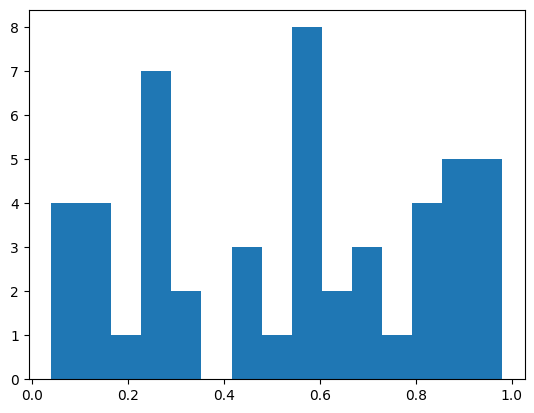

In [10]:
plt.hist(ps_abs2, bins=15)

In [12]:
np.savez("ps_garch_only.npz", p_values=ps_abs2)

In [2]:
data_msm = np.load("all_paths_msm.npz")['r']
data_figarch = np.load("all_paths_figarch.npz")['r']
data_garch = np.load("all_paths_garch2.npz")['r']
datas = [data_msm, data_figarch, data_garch]
names = ["BMSM", "FIGARCH", "GARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_abs = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-10,
        q_max=10,
        m=1,
        steps=10,
        type=types[2],
        models=names, 
        block=None, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

analyser_abs.get_plots()


Processing model BMSM, path 1/500
Processing model BMSM, path 101/500


/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_classes.py:257: SyntaxWarning: invalid escape sequence '\s'
  SE(\bar{f_alpha}) = \frac{\sigma_{f_alpha}}{\sqrt{n}})
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_classes.py:797: SyntaxWarning: invalid escape sequence '\s'
  RV = \sum_{i=1}^{n} r_i^2 where n is number of returns in the day.
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_classes.py:1458: SyntaxWarning: invalid escape sequence '\s'
  RV = \sum_{i=1}^{n} r_i^2 where n is number of returns in the day.
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_new.py:32: SyntaxWarning: invalid escape sequence '\d'
  F^2(v,s) = \dfrac{1}{s} \sum_{i=1}^s [Y_{(v-1)s + i} - y_{v,i}]^2,
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_new.py:291: SyntaxWarning: invalid escape sequence '\m'
  dF_q^2(s) = \max[F_q^2(s)] - \min[F_q^2(s)]


KeyboardInterrupt: 

Processing model BMSM, path 1/500
Processing model BMSM, path 101/500
Processing model BMSM, path 201/500
Processing model BMSM, path 301/500
Processing model BMSM, path 401/500
Processing model FIGARCH ($d=0.45$), path 1/500
Processing model FIGARCH ($d=0.45$), path 101/500
Processing model FIGARCH ($d=0.45$), path 201/500
Processing model FIGARCH ($d=0.45$), path 301/500
Processing model FIGARCH ($d=0.45$), path 401/500
Processing model FIGARCH ($d=0.85$), path 1/500
Processing model FIGARCH ($d=0.85$), path 101/500
Processing model FIGARCH ($d=0.85$), path 201/500
Processing model FIGARCH ($d=0.85$), path 301/500
Processing model FIGARCH ($d=0.85$), path 401/500
Processing model GARCH, path 1/500
Processing model GARCH, path 101/500
Processing model GARCH, path 201/500
Processing model GARCH, path 301/500
Processing model GARCH, path 401/500


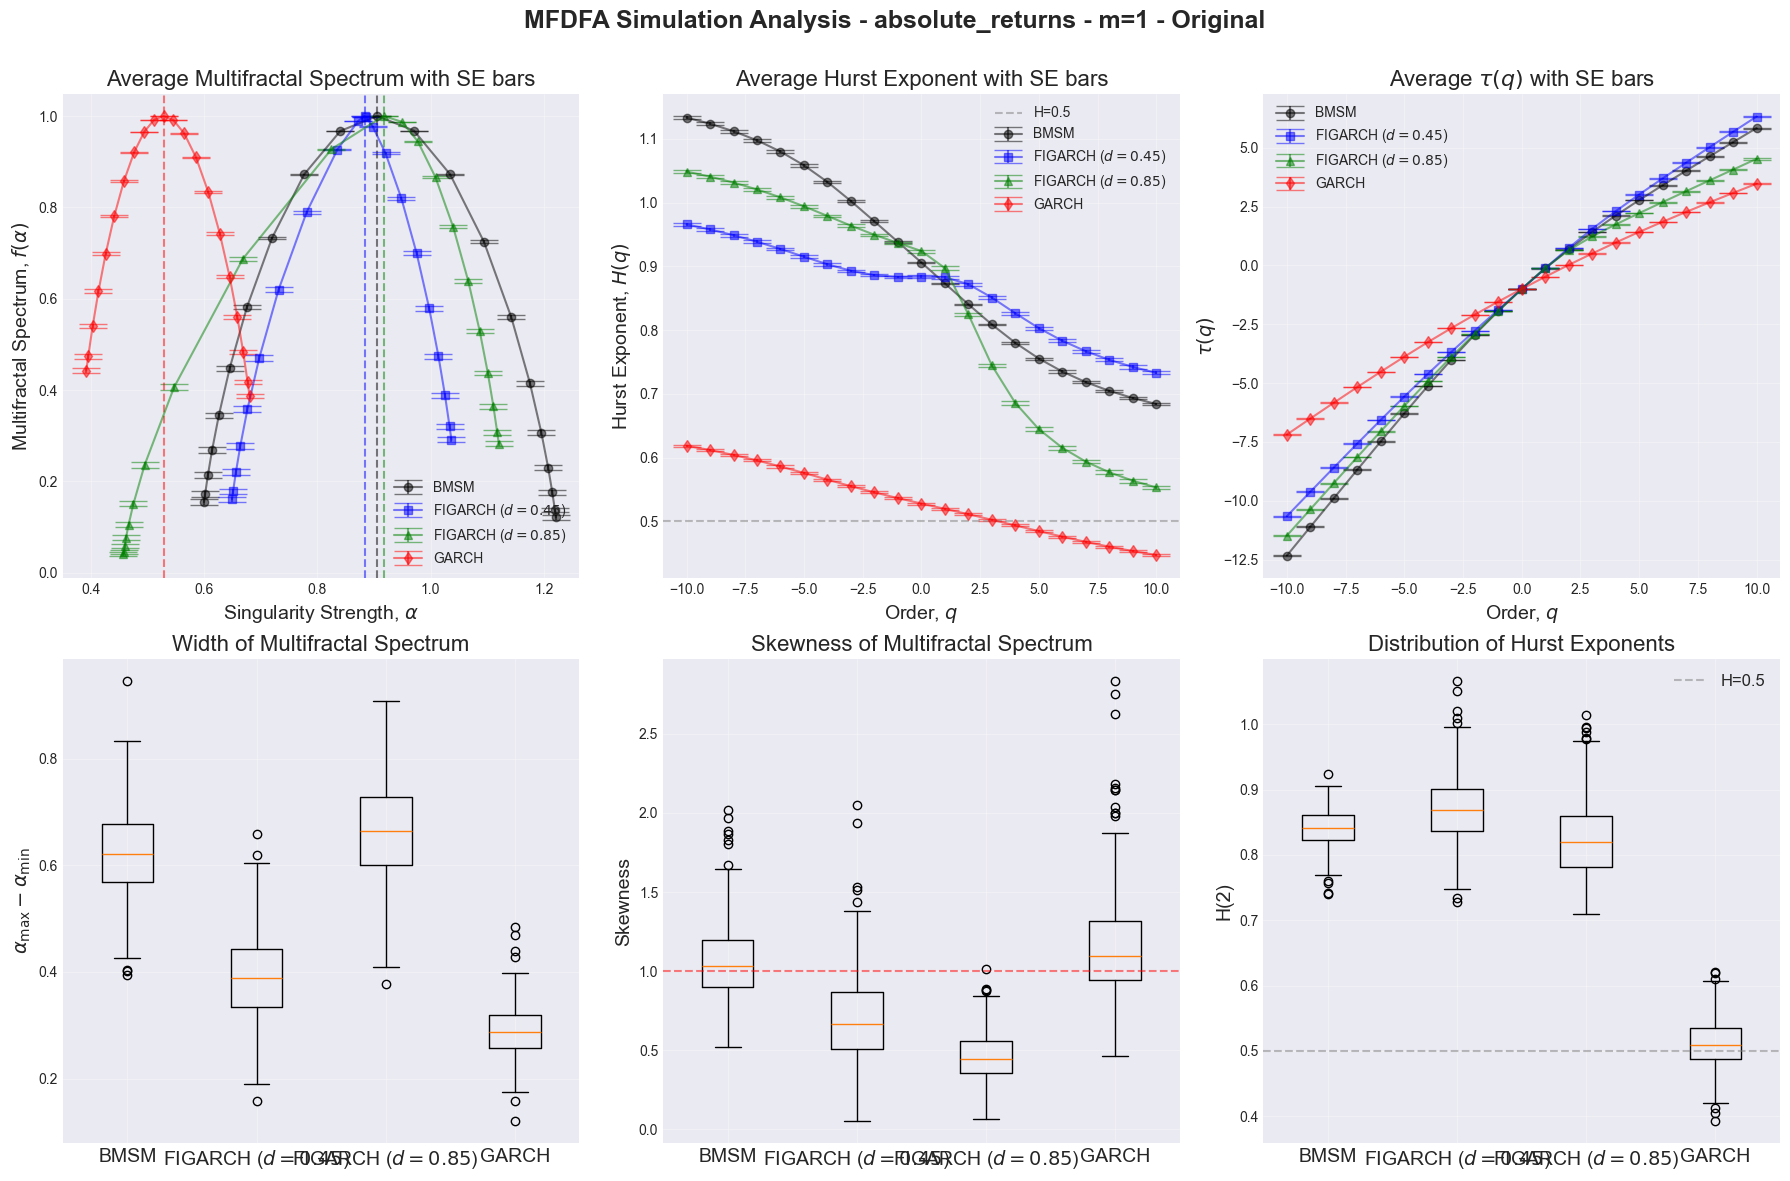

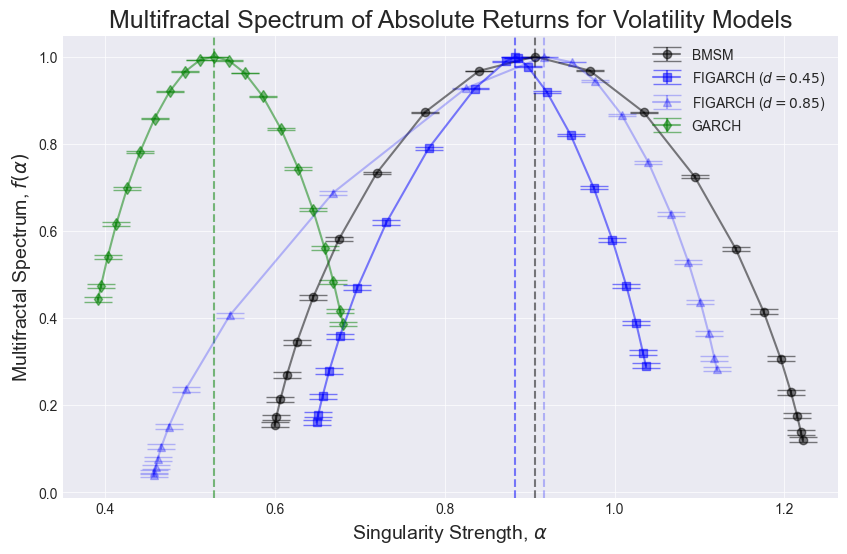

In [2]:
data_msm = np.load("all_paths_msm.npz")['r']
data_figarch = np.load("all_paths_figarch.npz")['r']
data_figarch2 = np.load("all_paths_figarch_d_8.npz")['r']
data_garch = np.load("all_paths_garch2.npz")['r']
datas = [data_msm, data_figarch, data_figarch2, data_garch]
names = ["BMSM", r"FIGARCH ($d=0.45$)", r"FIGARCH ($d=0.85$)", "GARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_abs = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-10,
        q_max=10,
        m=1,
        steps=10,
        type=types[2],
        models=names, 
        block=None, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

analyser_abs.get_plots()


In [5]:
np.savez("surrogate_tests_absolute_returns.npz", p_values=ps_abs)

In [6]:
data_msm = np.load("all_paths_msm.npz")['r']
data_figarch = np.load("all_paths_figarch.npz")['r']
data_heston= np.load("all_paths_heston_jumps.npz")['r']
data_msgarch = np.load("all_paths_msgarch.npz")['r']
datas = [data_msm, data_figarch, data_heston, data_msgarch]
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_squ_r = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-50,
        q_max=50,
        m=1,
        steps=10,
        type=types[1],
        models=names, 
        block=None, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

ps_squ = analyser_squ_r.surrogate_tests()


Generating surrogates for model MSM, path 1/50
Generating surrogates for model MSM, path 5/50
Generating surrogates for model MSM, path 9/50
Generating surrogates for model MSM, path 13/50
Generating surrogates for model MSM, path 17/50
Generating surrogates for model MSM, path 21/50
Generating surrogates for model MSM, path 25/50
Generating surrogates for model MSM, path 29/50
Generating surrogates for model MSM, path 33/50
Generating surrogates for model MSM, path 37/50
Generating surrogates for model MSM, path 41/50
Generating surrogates for model MSM, path 45/50
Generating surrogates for model MSM, path 49/50
Generating surrogates for model FIGARCH, path 1/50
Generating surrogates for model FIGARCH, path 5/50
Generating surrogates for model FIGARCH, path 9/50
Generating surrogates for model FIGARCH, path 13/50
Generating surrogates for model FIGARCH, path 17/50
Generating surrogates for model FIGARCH, path 21/50
Generating surrogates for model FIGARCH, path 25/50
Generating surroga

/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_new.py:253: RuntimeWarning: overflow encountered in float_power
  np.mean(np.float_power(F, q_safe / 2)),
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_functions.py:120: RuntimeWarning: divide by zero encountered in log
  log_Fq = np.log(F_q)
/Users/alexvillamartin/Documents/MSc Diss/Code/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


Processing surrogates for model MSM, path 5/50
Processing surrogates for model MSM, path 9/50
Processing surrogates for model MSM, path 13/50
Processing surrogates for model MSM, path 17/50
Processing surrogates for model MSM, path 21/50
Processing surrogates for model MSM, path 25/50
Processing surrogates for model MSM, path 29/50
Processing surrogates for model MSM, path 33/50
Processing surrogates for model MSM, path 37/50
Processing surrogates for model MSM, path 41/50
Processing surrogates for model MSM, path 45/50
Processing surrogates for model MSM, path 49/50
Processing surrogates for model FIGARCH, path 1/50
Processing surrogates for model FIGARCH, path 5/50
Processing surrogates for model FIGARCH, path 9/50
Processing surrogates for model FIGARCH, path 13/50
Processing surrogates for model FIGARCH, path 17/50
Processing surrogates for model FIGARCH, path 21/50
Processing surrogates for model FIGARCH, path 25/50
Processing surrogates for model FIGARCH, path 29/50
Processing su

In [7]:
np.savez("surrogate_tests_squared_r.npz", p_values=ps_squ)

In [36]:
data_msm = np.load("all_paths_msm.npz")['r']
data_figarch = np.load("all_paths_figarch.npz")['r']
data_heston= np.load("all_paths_heston_jumps.npz")['r']
data_msgarch = np.load("all_paths_msgarch.npz")['r']
datas = [data_msm, data_figarch, data_heston, data_msgarch]
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_bv = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-50,
        q_max=50,
        m=1,
        steps=10,
        type=types[3],
        models=names, 
        block=10, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

ps_bv = analyser_bv.surrogate_tests()


Generating surrogates for model MSM, path 1/50
Generating surrogates for model MSM, path 5/50
Generating surrogates for model MSM, path 9/50
Generating surrogates for model MSM, path 13/50
Generating surrogates for model MSM, path 17/50
Generating surrogates for model MSM, path 21/50
Generating surrogates for model MSM, path 25/50
Generating surrogates for model MSM, path 29/50
Generating surrogates for model MSM, path 33/50
Generating surrogates for model MSM, path 37/50
Generating surrogates for model MSM, path 41/50
Generating surrogates for model MSM, path 45/50
Generating surrogates for model MSM, path 49/50
Generating surrogates for model FIGARCH, path 1/50
Generating surrogates for model FIGARCH, path 5/50
Generating surrogates for model FIGARCH, path 9/50
Generating surrogates for model FIGARCH, path 13/50
Generating surrogates for model FIGARCH, path 17/50
Generating surrogates for model FIGARCH, path 21/50
Generating surrogates for model FIGARCH, path 25/50
Generating surroga

In [37]:
np.savez("surrogate_tests_block_vol.npz", p_values=ps_bv)

# do actual true vol

Processing model MSM, path 1/500


/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_new.py:253: RuntimeWarning: divide by zero encountered in float_power
  np.mean(np.float_power(F, q_safe / 2)),
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_new.py:253: RuntimeWarning: overflow encountered in float_power
  np.mean(np.float_power(F, q_safe / 2)),


Processing model MSM, path 101/500
Processing model MSM, path 201/500
Processing model MSM, path 301/500
Processing model MSM, path 401/500
Processing model FIGARCH, path 1/500
Processing model FIGARCH, path 101/500
Processing model FIGARCH, path 201/500
Processing model FIGARCH, path 301/500
Processing model FIGARCH, path 401/500
Processing model Heston, path 1/500
Processing model Heston, path 101/500
Processing model Heston, path 201/500
Processing model Heston, path 301/500
Processing model Heston, path 401/500
Processing model MSGARCH, path 1/500
Processing model MSGARCH, path 101/500
Processing model MSGARCH, path 201/500
Processing model MSGARCH, path 301/500
Processing model MSGARCH, path 401/500


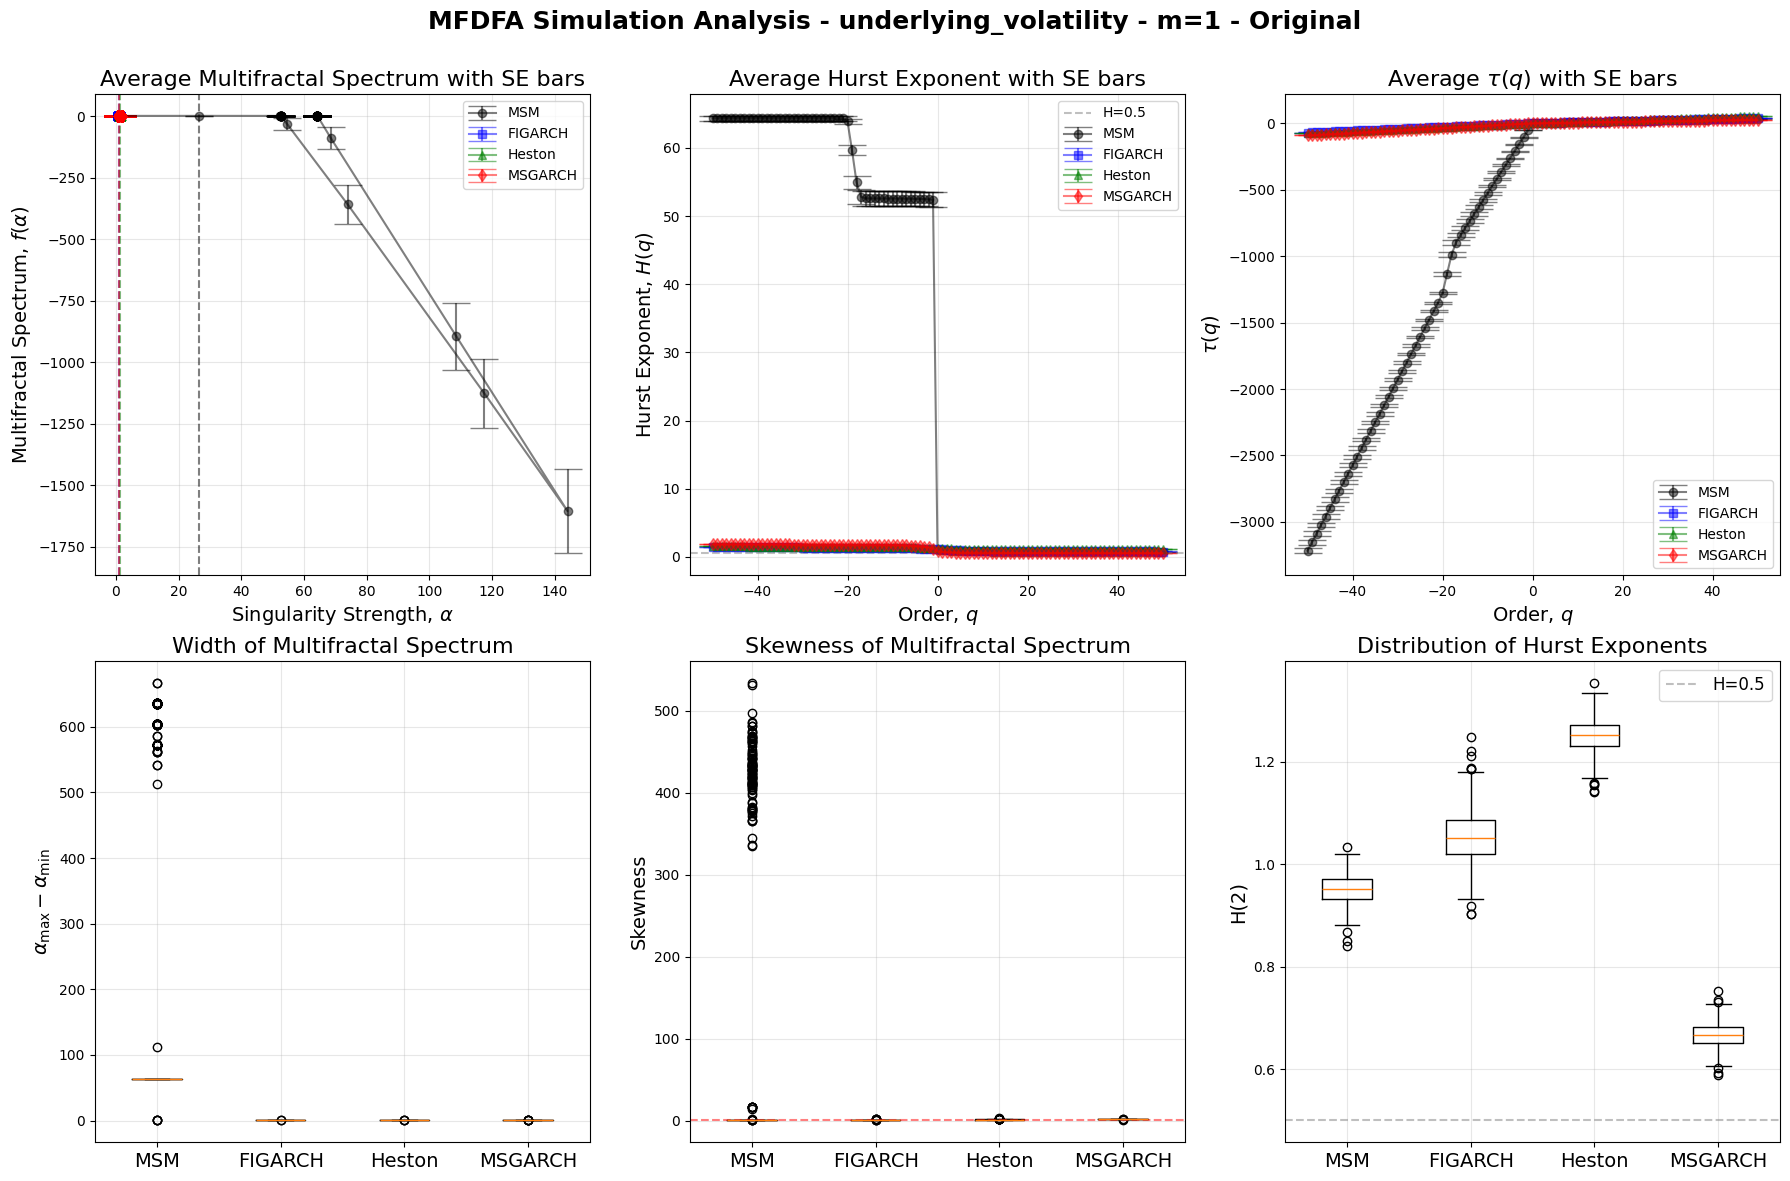

In [2]:
data_msm = np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/Old paths/all_paths_msm_backup.npz")['h'][1:, :] ** 0.5
data_figarch = np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/Old paths/all_paths_figarch_backup.npz")['h'][1:, :] ** 0.5
data_heston= np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/Old paths/all_paths_heston_jumps_backup.npz")['h'][1:, :] ** 0.5
data_msgarch = np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/Old paths/all_paths_msgarch_backup.npz")['h'][1:, :] ** 0.5
datas = [data_msm, data_figarch, data_heston, data_msgarch]
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['underlying_volatility', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_raw_r = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-50,
        q_max=50,
        m=1,
        steps=10,
        type=types[0],
        models=names, 
        block=None, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

analyser_raw_r.get_plots()


Processing model MSM, path 1/500


/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_new.py:253: RuntimeWarning: overflow encountered in float_power
  np.mean(np.float_power(F, q_safe / 2)),
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_functions.py:120: RuntimeWarning: divide by zero encountered in log
  log_Fq = np.log(F_q)
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_new.py:253: RuntimeWarning: divide by zero encountered in float_power
  np.mean(np.float_power(F, q_safe / 2)),


Processing model MSM, path 101/500
Processing model MSM, path 201/500
Processing model MSM, path 301/500


/Users/alexvillamartin/Documents/MSc Diss/Code/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


Processing model MSM, path 401/500
Processing model FIGARCH, path 1/500
Processing model FIGARCH, path 101/500
Processing model FIGARCH, path 201/500
Processing model FIGARCH, path 301/500
Processing model FIGARCH, path 401/500
Processing model Heston, path 1/500
Processing model Heston, path 101/500
Processing model Heston, path 201/500
Processing model Heston, path 301/500
Processing model Heston, path 401/500
Processing model MSGARCH, path 1/500
Processing model MSGARCH, path 101/500
Processing model MSGARCH, path 201/500
Processing model MSGARCH, path 301/500
Processing model MSGARCH, path 401/500


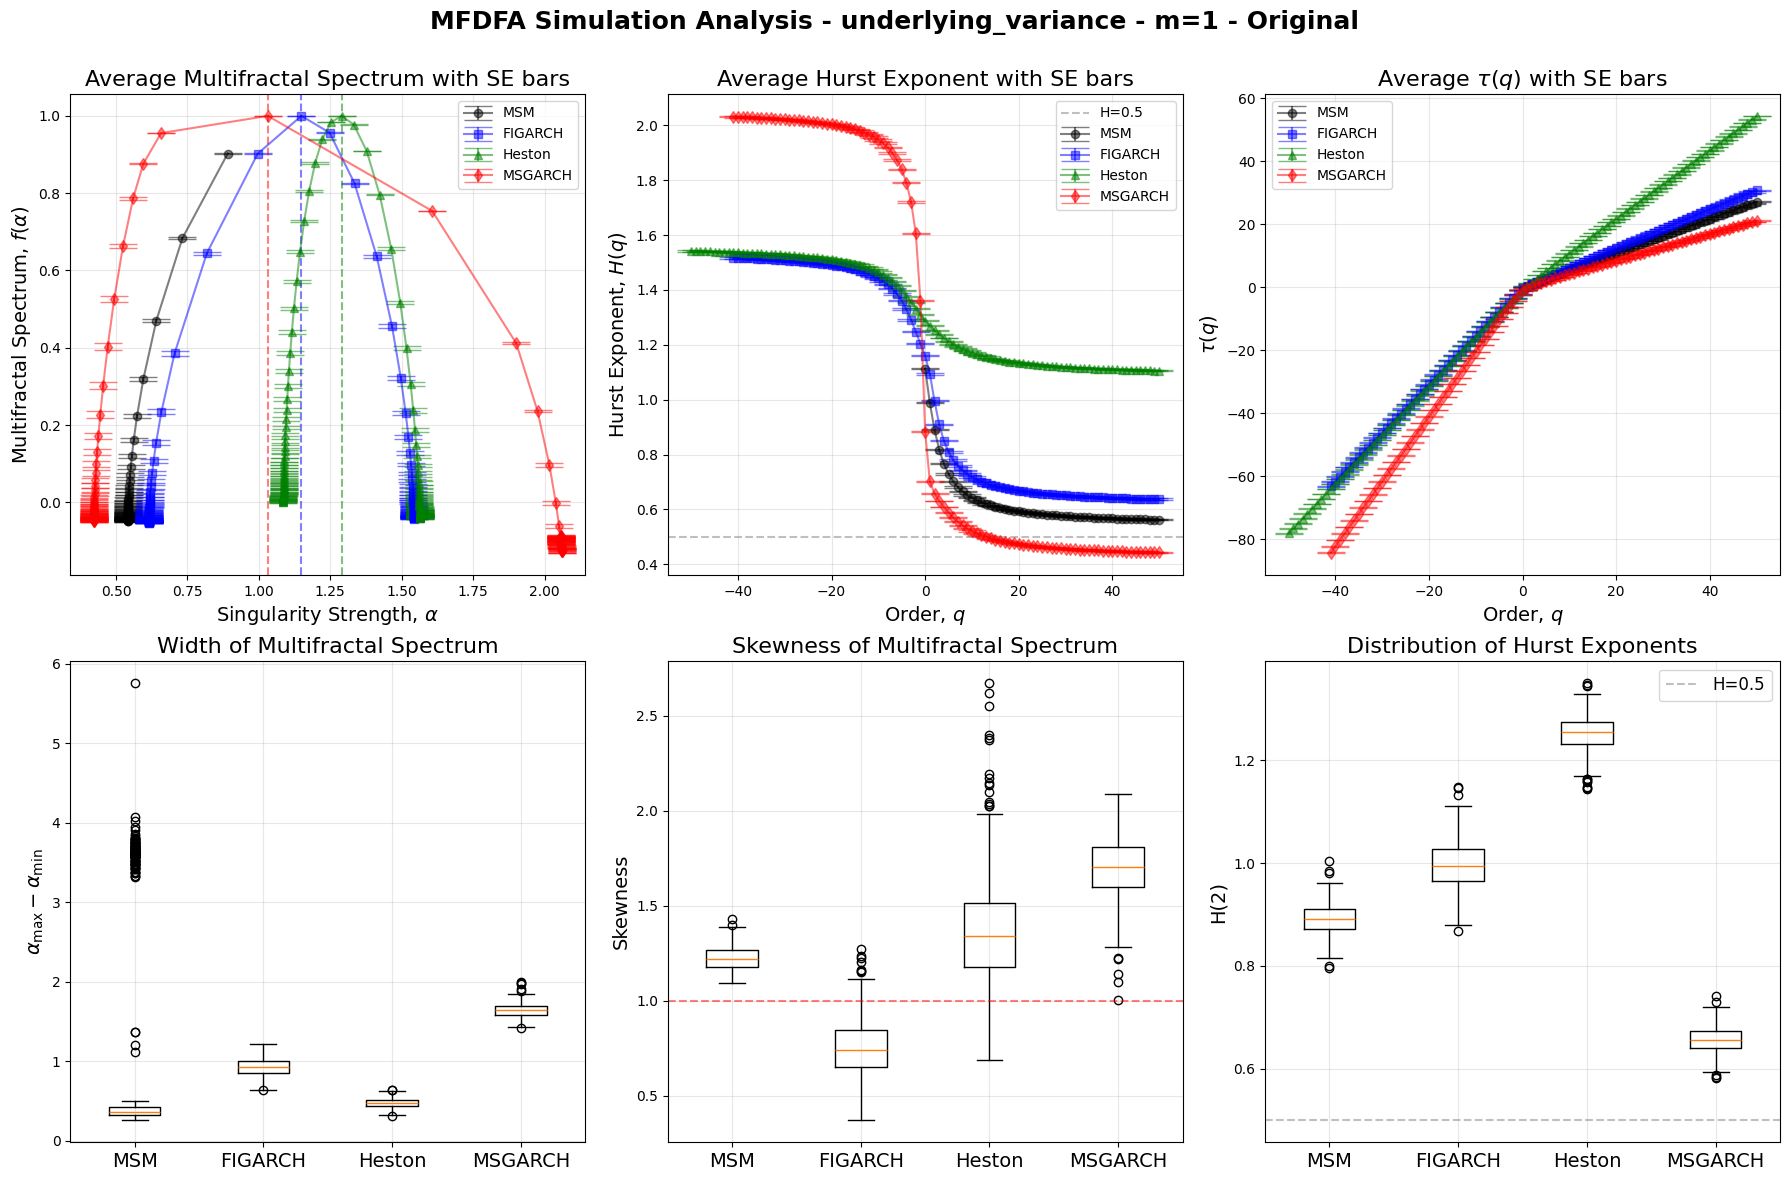

In [6]:
data_msm = np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/Old paths/all_paths_msm_backup.npz")['h'][1:, :] 
data_figarch = np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/Old paths/all_paths_figarch_backup.npz")['h'][1:, :] 
data_heston= np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/Old paths/all_paths_heston_jumps_backup.npz")['h'][1:, :] 
data_msgarch = np.load("/Users/alexvillamartin/Documents/MSc Diss/Code/Old paths/all_paths_msgarch_backup.npz")['h'][1:, :] 
datas = [data_msm, data_figarch, data_heston, data_msgarch]
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['underlying_variance', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_raw_r = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-50,
        q_max=50,
        m=1,
        steps=10,
        type=types[0],
        models=names, 
        block=None, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

analyser_raw_r.get_plots()


# HERE

Processing model MSM, path 1/500
Processing model MSM, path 101/500
Processing model MSM, path 201/500
Processing model MSM, path 301/500
Processing model MSM, path 401/500
Processing model FIGARCH, path 1/500
Processing model FIGARCH, path 101/500
Processing model FIGARCH, path 201/500
Processing model FIGARCH, path 301/500
Processing model FIGARCH, path 401/500
Processing model Heston, path 1/500
Processing model Heston, path 101/500
Processing model Heston, path 201/500
Processing model Heston, path 301/500
Processing model Heston, path 401/500
Processing model MSGARCH, path 1/500
Processing model MSGARCH, path 101/500
Processing model MSGARCH, path 201/500
Processing model MSGARCH, path 301/500
Processing model MSGARCH, path 401/500
Processing model MSGARCH_Jumps, path 1/500
Processing model MSGARCH_Jumps, path 101/500
Processing model MSGARCH_Jumps, path 201/500
Processing model MSGARCH_Jumps, path 301/500
Processing model MSGARCH_Jumps, path 401/500


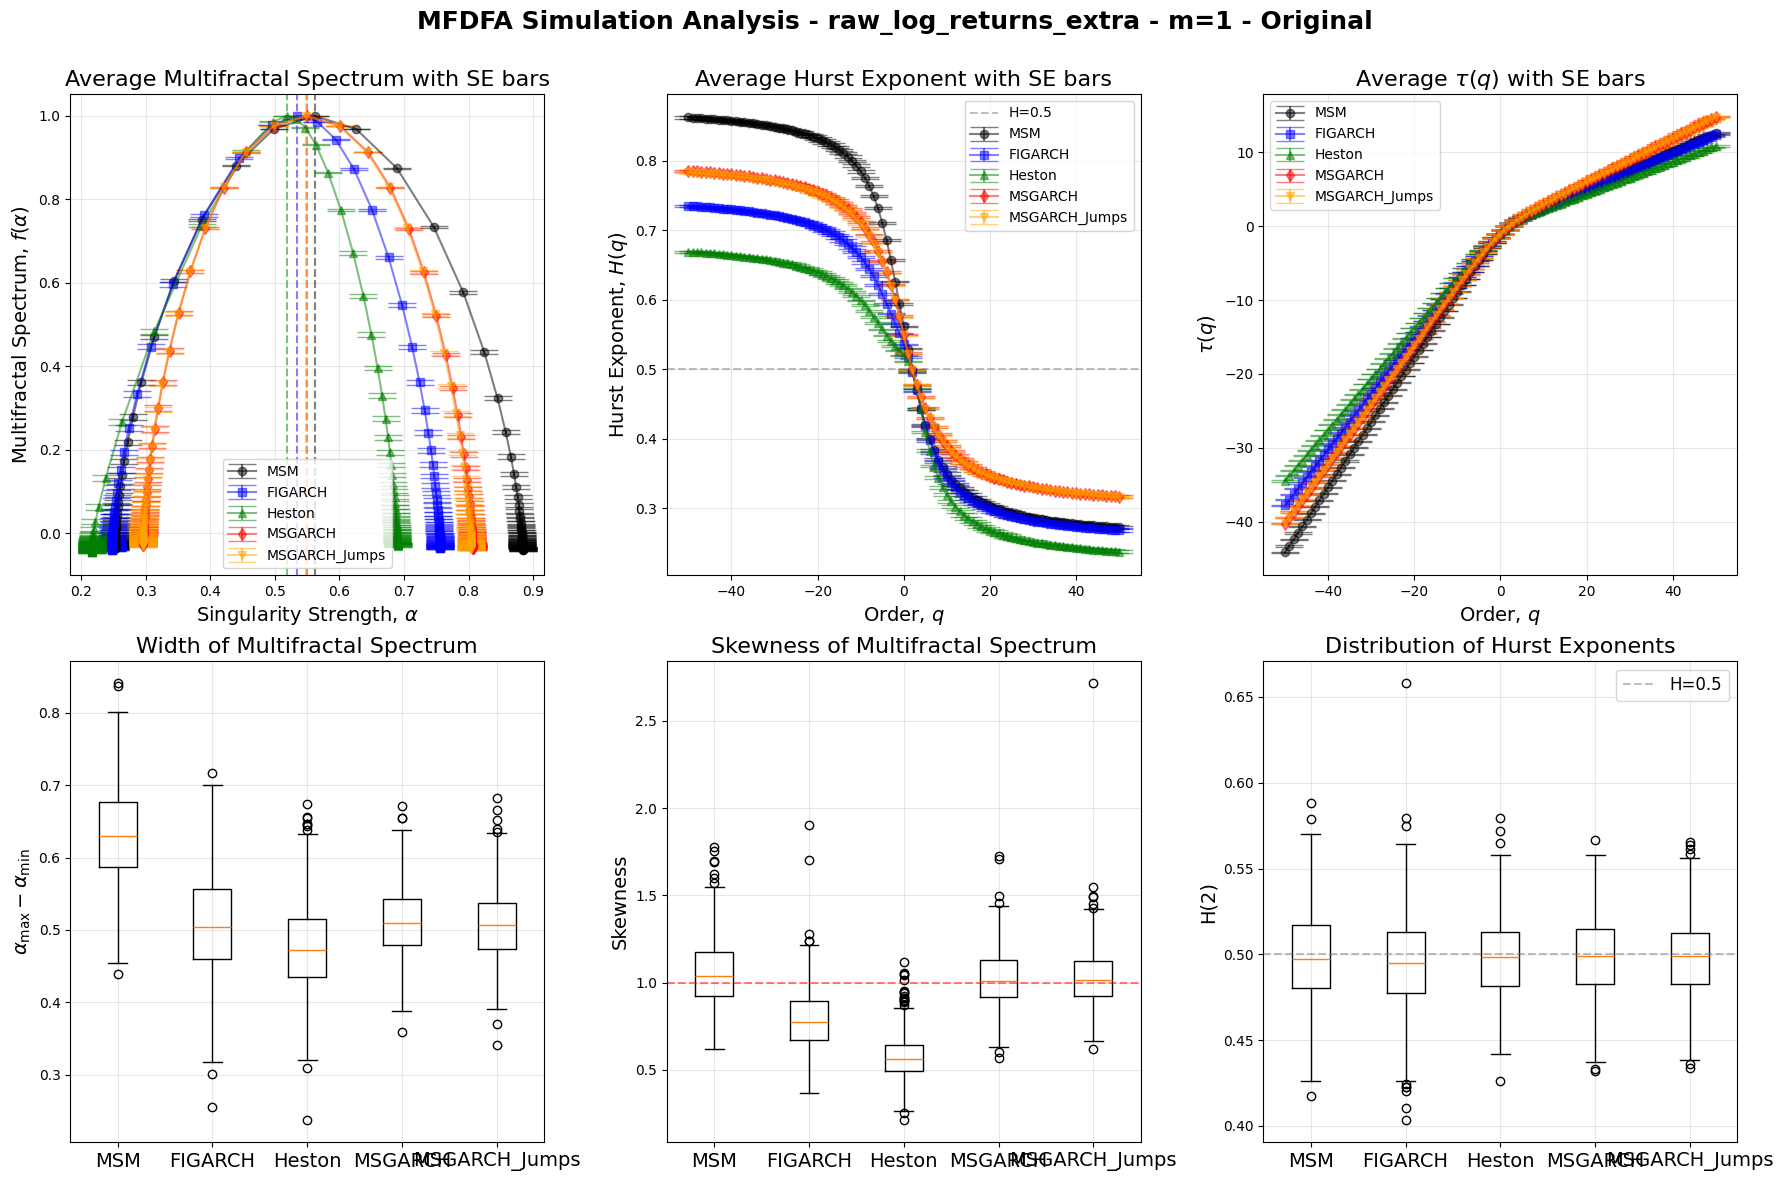

In [6]:
data_msm = np.load("all_paths_msm.npz")['r']
data_figarch = np.load("all_paths_figarch.npz")['r']
data_heston= np.load("all_paths_heston_jumps.npz")['r']
data_msgarch = np.load("all_paths_msgarch.npz")['r']
data_msgarch_jumps = np.load("all_paths_msgarch_with_jumps.npz")['r']
datas = [data_msm, data_figarch, data_heston, data_msgarch, data_msgarch_jumps]
names = ["MSM", "FIGARCH", "Heston", "MSGARCH", "MSGARCH_Jumps"]  
types = ['raw_log_returns_extra', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_raw_r = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-50,
        q_max=50,
        m=1,
        steps=10,
        type=types[0],
        models=names, 
        block=None, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

analyser_raw_r.get_plots()


Processing model MSM, path 1/500
Processing model MSM, path 101/500
Processing model MSM, path 201/500
Processing model MSM, path 301/500
Processing model MSM, path 401/500
Processing model FIGARCH, path 1/500
Processing model FIGARCH, path 101/500
Processing model FIGARCH, path 201/500
Processing model FIGARCH, path 301/500
Processing model FIGARCH, path 401/500
Processing model Heston, path 1/500
Processing model Heston, path 101/500
Processing model Heston, path 201/500
Processing model Heston, path 301/500
Processing model Heston, path 401/500
Processing model MSGARCH, path 1/500
Processing model MSGARCH, path 101/500
Processing model MSGARCH, path 201/500
Processing model MSGARCH, path 301/500
Processing model MSGARCH, path 401/500


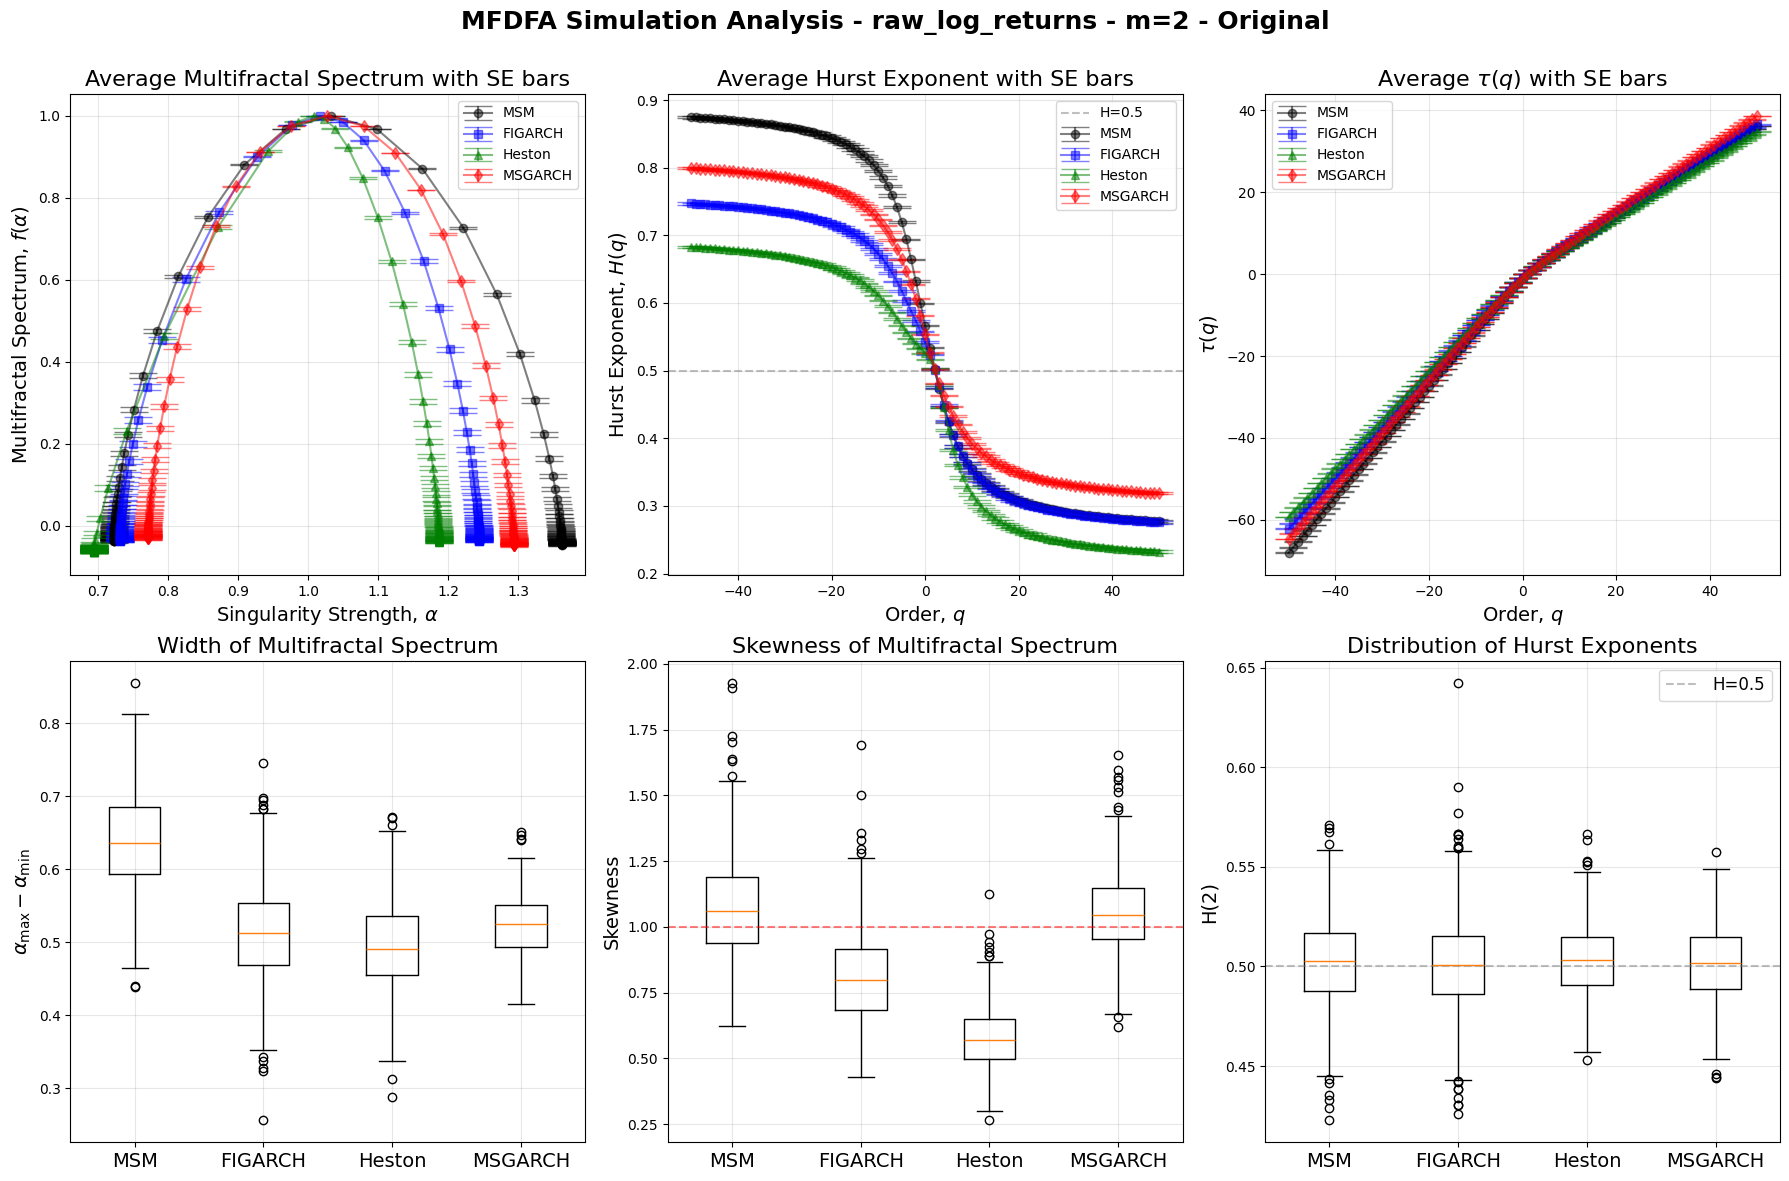

In [2]:
data_msm = np.load("all_paths_msm.npz")['r']
data_figarch = np.load("all_paths_figarch.npz")['r']
data_heston= np.load("all_paths_heston_jumps.npz")['r']
data_msgarch = np.load("all_paths_msgarch.npz")['r']
datas = [data_msm, data_figarch, data_heston, data_msgarch]
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_raw_r = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-50,
        q_max=50,
        m=2,
        steps=10,
        type=types[0],
        models=names, 
        block=None, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

analyser_raw_r.get_plots()


Processing model MSM, path 1/500
Processing model MSM, path 101/500
Processing model MSM, path 201/500
Processing model MSM, path 301/500
Processing model MSM, path 401/500
Processing model FIGARCH, path 1/500
Processing model FIGARCH, path 101/500
Processing model FIGARCH, path 201/500
Processing model FIGARCH, path 301/500
Processing model FIGARCH, path 401/500
Processing model Heston, path 1/500
Processing model Heston, path 101/500
Processing model Heston, path 201/500
Processing model Heston, path 301/500
Processing model Heston, path 401/500
Processing model MSGARCH, path 1/500
Processing model MSGARCH, path 101/500
Processing model MSGARCH, path 201/500
Processing model MSGARCH, path 301/500
Processing model MSGARCH, path 401/500


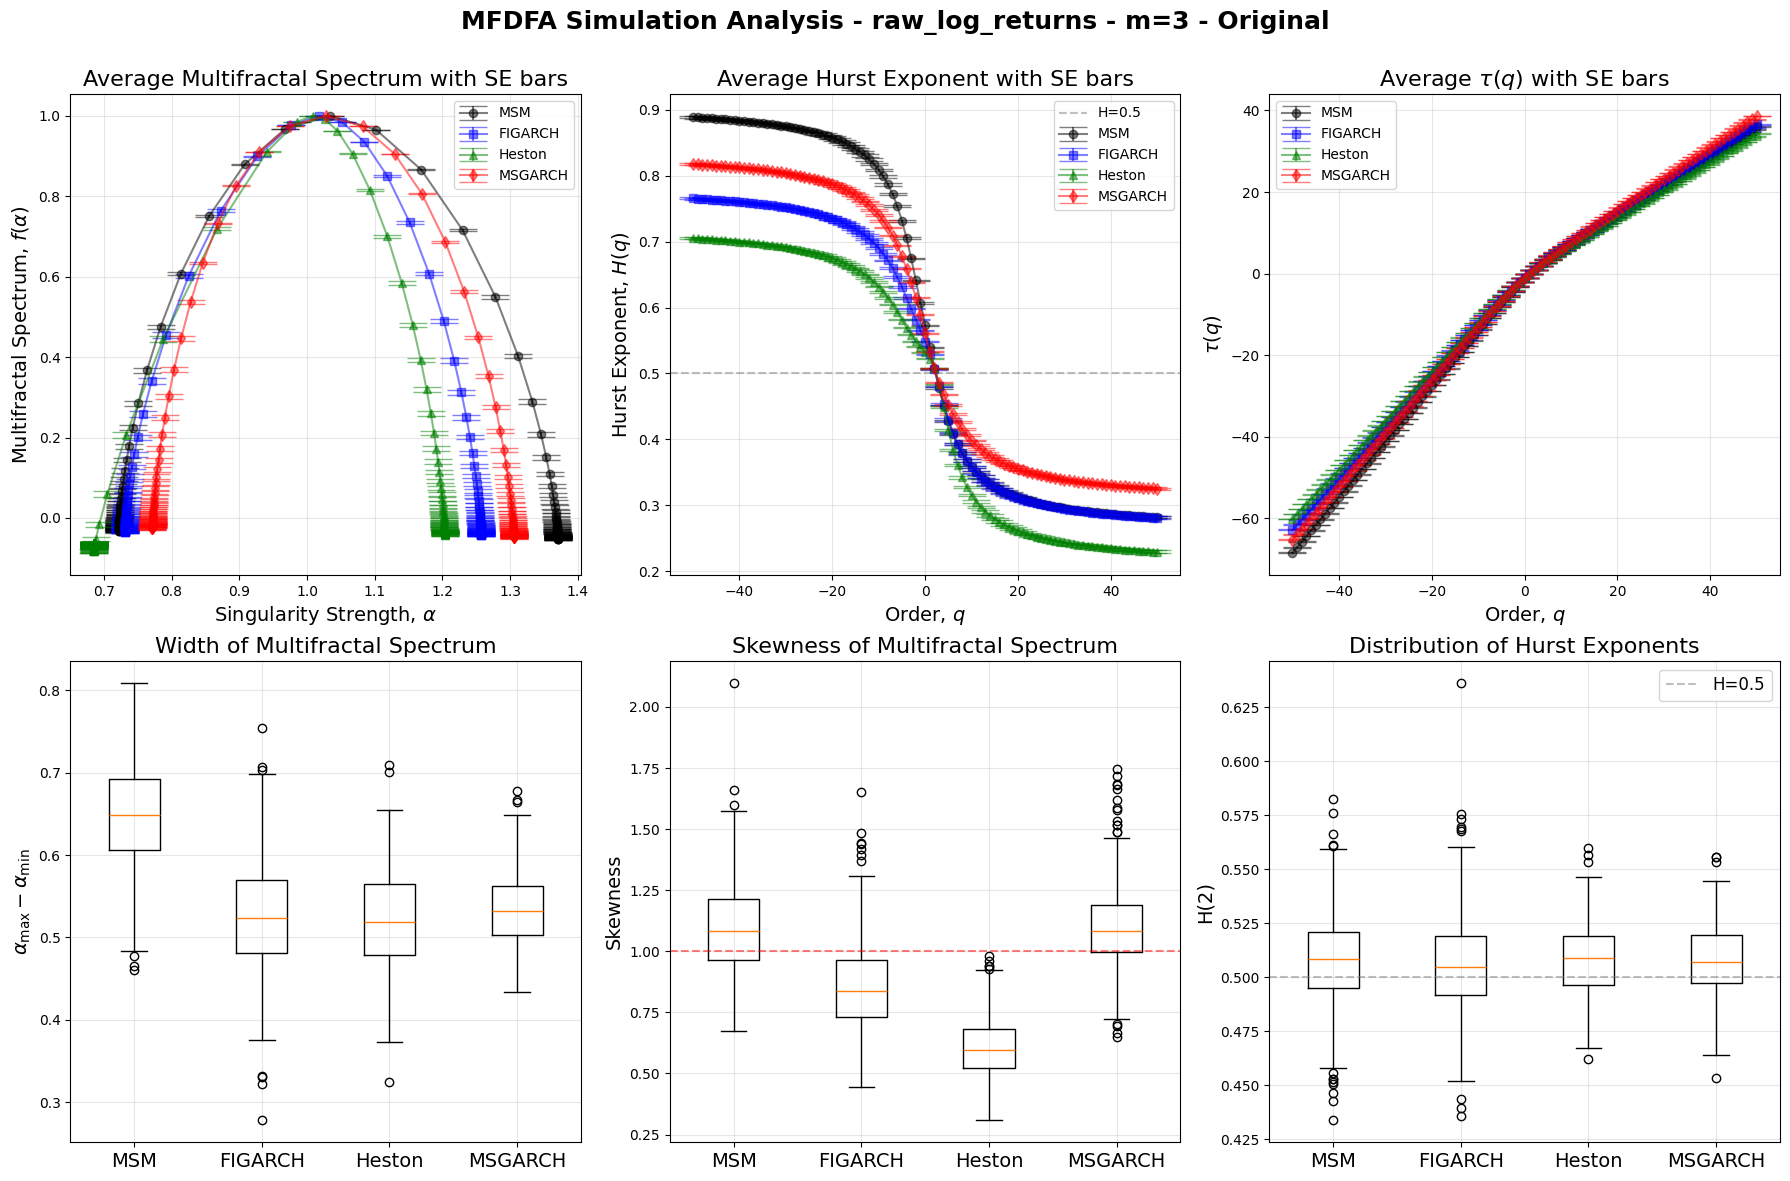

In [3]:
data_msm = np.load("all_paths_msm.npz")['r']
data_figarch = np.load("all_paths_figarch.npz")['r']
data_heston= np.load("all_paths_heston_jumps.npz")['r']
data_msgarch = np.load("all_paths_msgarch.npz")['r']
datas = [data_msm, data_figarch, data_heston, data_msgarch]
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_raw_r = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-50,
        q_max=50,
        m=3,
        steps=10,
        type=types[0],
        models=names, 
        block=None, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

analyser_raw_r.get_plots()


Processing model MSM, path 1/500


/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_new.py:253: RuntimeWarning: overflow encountered in float_power
  np.mean(np.float_power(F, q_safe / 2)),
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_functions.py:120: RuntimeWarning: divide by zero encountered in log
  log_Fq = np.log(F_q)
/Users/alexvillamartin/Documents/MSc Diss/Code/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


Processing model MSM, path 101/500
Processing model MSM, path 201/500
Processing model MSM, path 301/500
Processing model MSM, path 401/500
Processing model FIGARCH, path 1/500
Processing model FIGARCH, path 101/500
Processing model FIGARCH, path 201/500
Processing model FIGARCH, path 301/500
Processing model FIGARCH, path 401/500
Processing model Heston, path 1/500
Processing model Heston, path 101/500
Processing model Heston, path 201/500
Processing model Heston, path 301/500
Processing model Heston, path 401/500
Processing model MSGARCH, path 1/500
Processing model MSGARCH, path 101/500
Processing model MSGARCH, path 201/500
Processing model MSGARCH, path 301/500
Processing model MSGARCH, path 401/500


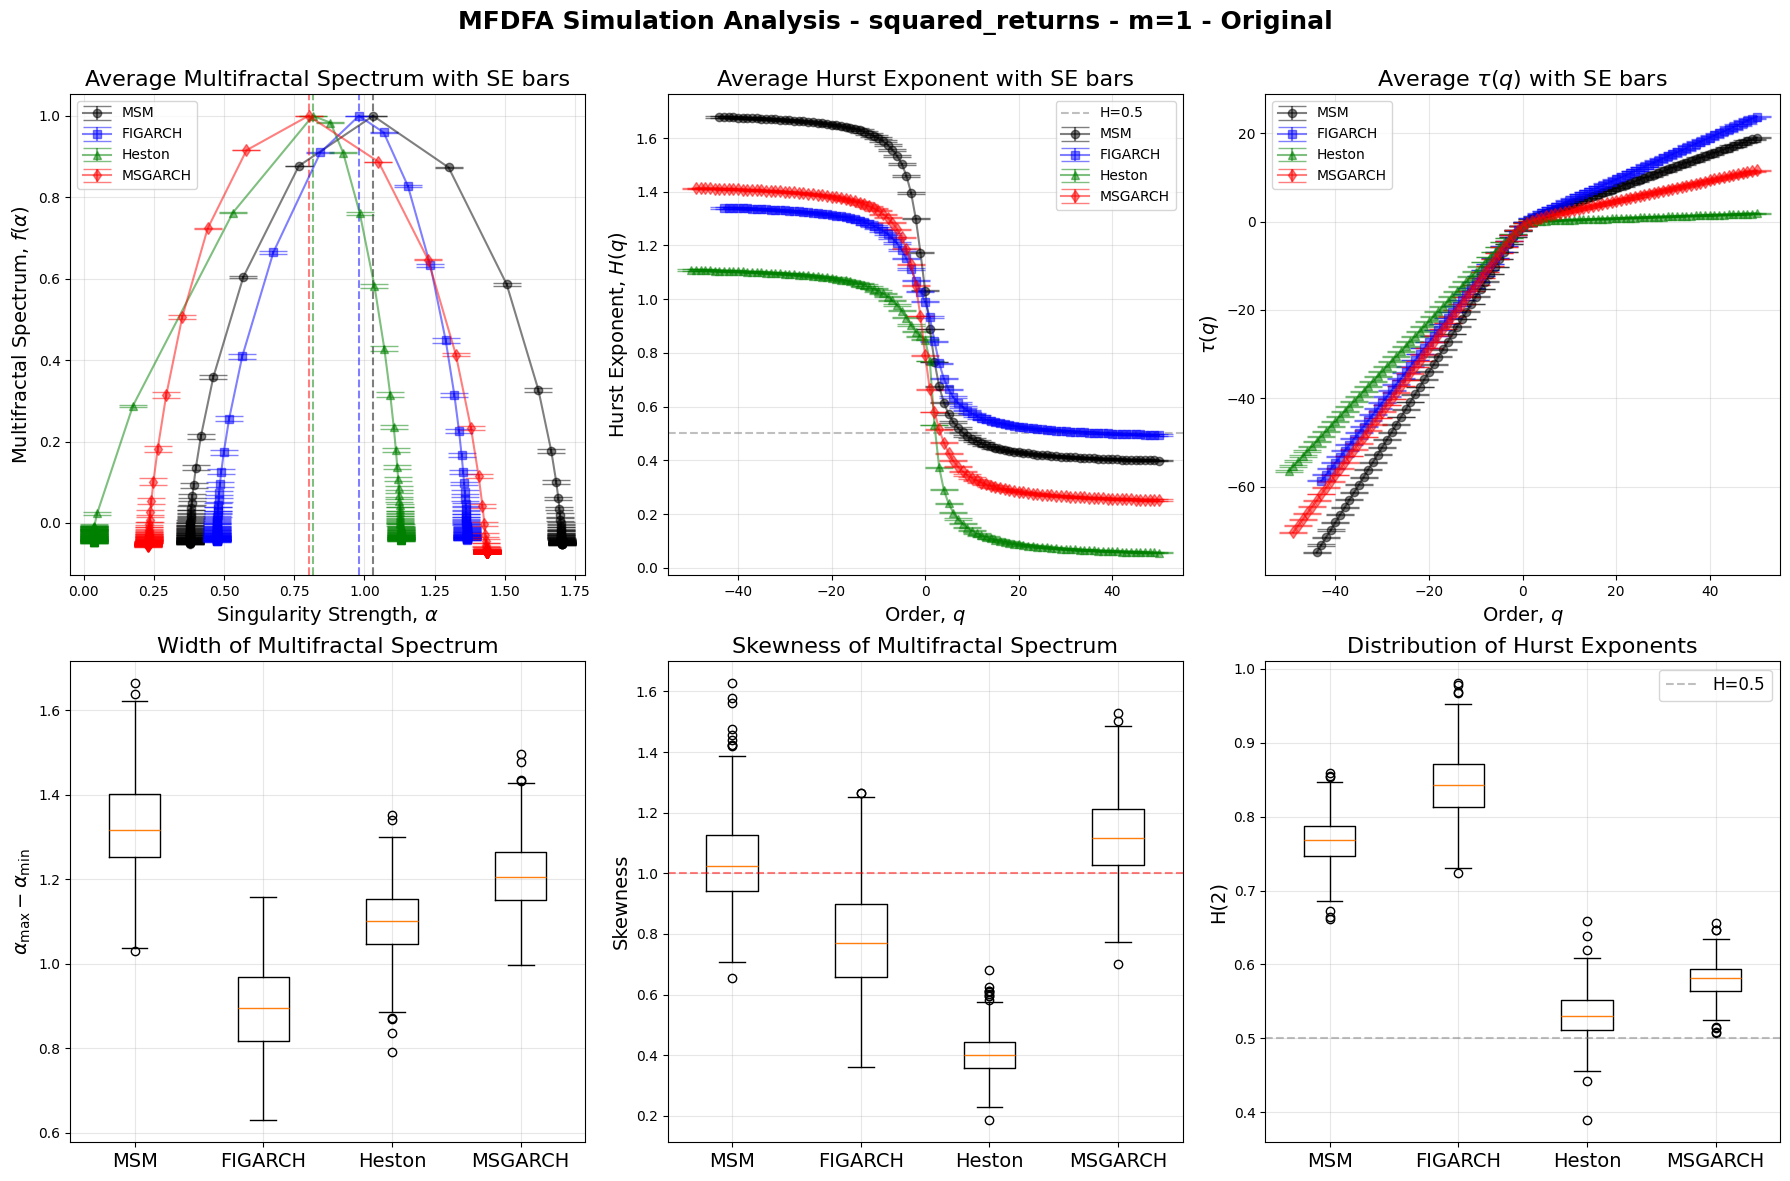

In [2]:
data_msm = np.load("all_paths_msm.npz")['r']
data_figarch = np.load("all_paths_figarch.npz")['r']
data_heston= np.load("all_paths_heston_jumps.npz")['r']
data_msgarch = np.load("all_paths_msgarch.npz")['r']
datas = [data_msm, data_figarch, data_heston, data_msgarch]
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_squ_r = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-50,
        q_max=50,
        m=1,
        steps=10,
        type=types[1],
        models=names, 
        block=None, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

analyser_squ_r.get_plots()


Processing model MSM, path 1/500


/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_new.py:253: RuntimeWarning: overflow encountered in float_power
  np.mean(np.float_power(F, q_safe / 2)),
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_functions.py:120: RuntimeWarning: divide by zero encountered in log
  log_Fq = np.log(F_q)
/Users/alexvillamartin/Documents/MSc Diss/Code/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


Processing model MSM, path 101/500
Processing model MSM, path 201/500
Processing model MSM, path 301/500
Processing model MSM, path 401/500
Processing model FIGARCH, path 1/500
Processing model FIGARCH, path 101/500
Processing model FIGARCH, path 201/500
Processing model FIGARCH, path 301/500
Processing model FIGARCH, path 401/500
Processing model Heston, path 1/500
Processing model Heston, path 101/500
Processing model Heston, path 201/500
Processing model Heston, path 301/500
Processing model Heston, path 401/500
Processing model MSGARCH, path 1/500
Processing model MSGARCH, path 101/500
Processing model MSGARCH, path 201/500
Processing model MSGARCH, path 301/500
Processing model MSGARCH, path 401/500


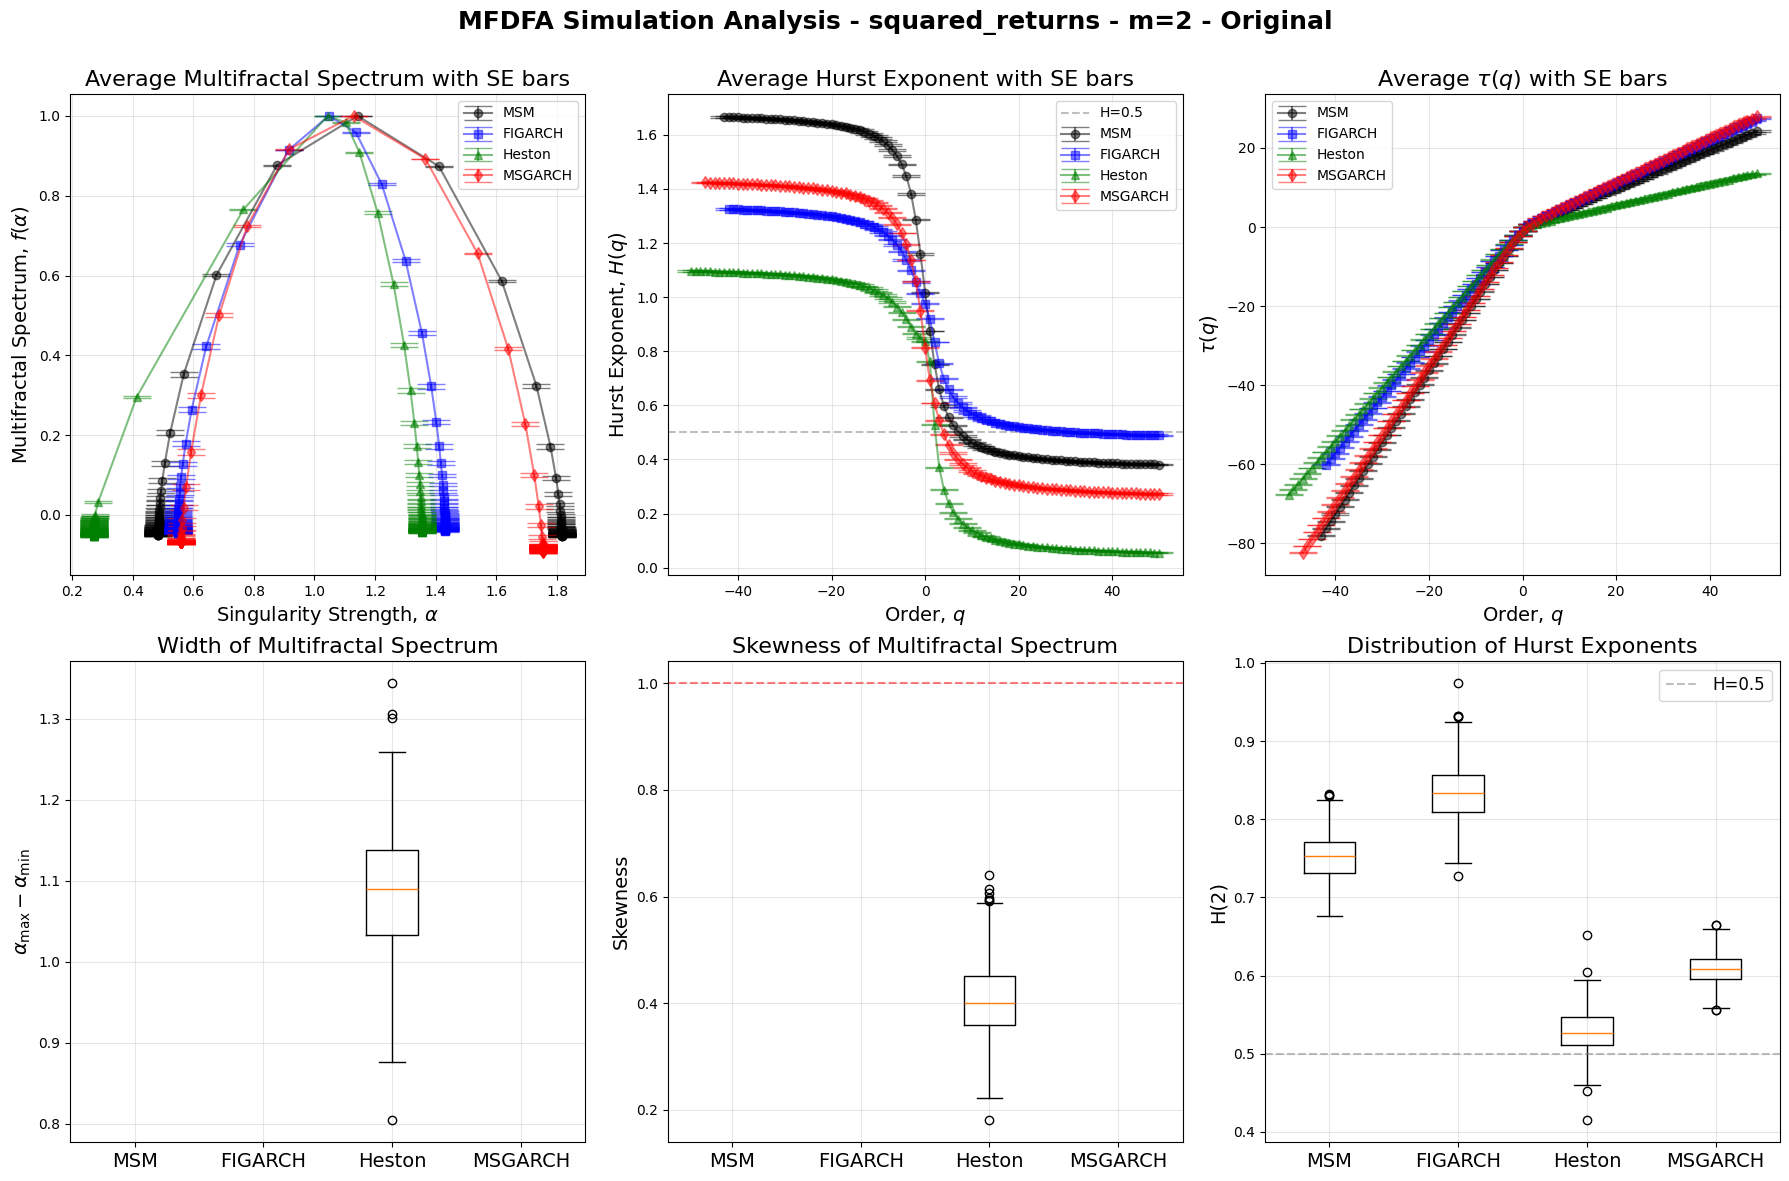

In [5]:
data_msm = np.load("all_paths_msm.npz")['r']
data_figarch = np.load("all_paths_figarch.npz")['r']
data_heston= np.load("all_paths_heston_jumps.npz")['r']
data_msgarch = np.load("all_paths_msgarch.npz")['r']
datas = [data_msm, data_figarch, data_heston, data_msgarch]
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_squ_r = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-50,
        q_max=50,
        m=2,
        steps=10,
        type=types[1],
        models=names, 
        block=None, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

analyser_squ_r.get_plots()


Processing model MSM, path 1/500


/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_new.py:253: RuntimeWarning: overflow encountered in float_power
  np.mean(np.float_power(F, q_safe / 2)),
/Users/alexvillamartin/Documents/MSc Diss/Code/MFDFA_functions.py:120: RuntimeWarning: divide by zero encountered in log
  log_Fq = np.log(F_q)


Processing model MSM, path 101/500


/Users/alexvillamartin/Documents/MSc Diss/Code/.venv/lib/python3.13/site-packages/numpy/_core/_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


Processing model MSM, path 201/500
Processing model MSM, path 301/500
Processing model MSM, path 401/500
Processing model FIGARCH, path 1/500
Processing model FIGARCH, path 101/500
Processing model FIGARCH, path 201/500
Processing model FIGARCH, path 301/500
Processing model FIGARCH, path 401/500
Processing model Heston, path 1/500
Processing model Heston, path 101/500
Processing model Heston, path 201/500
Processing model Heston, path 301/500
Processing model Heston, path 401/500
Processing model MSGARCH, path 1/500
Processing model MSGARCH, path 101/500
Processing model MSGARCH, path 201/500
Processing model MSGARCH, path 301/500
Processing model MSGARCH, path 401/500


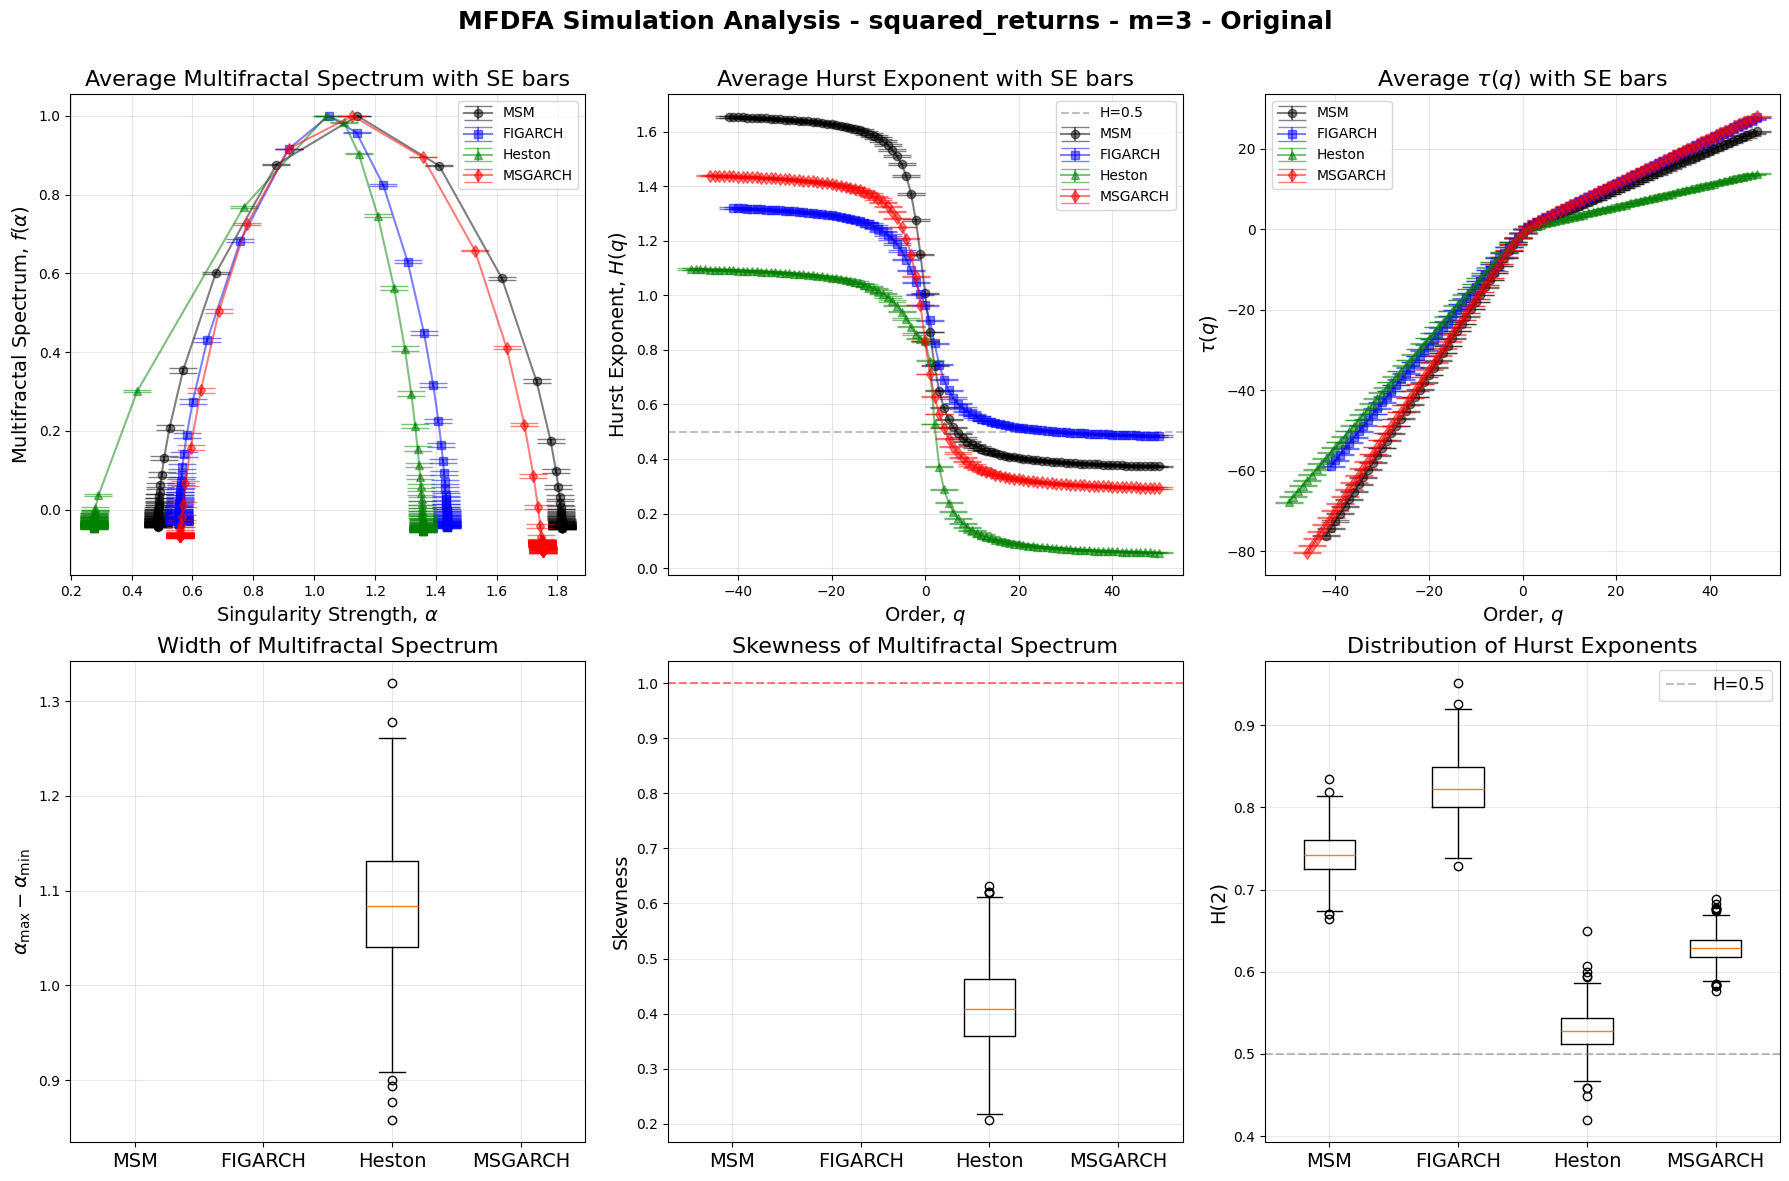

In [6]:
data_msm = np.load("all_paths_msm.npz")['r']
data_figarch = np.load("all_paths_figarch.npz")['r']
data_heston= np.load("all_paths_heston_jumps.npz")['r']
data_msgarch = np.load("all_paths_msgarch.npz")['r']
datas = [data_msm, data_figarch, data_heston, data_msgarch]
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_squ_r = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-50,
        q_max=50,
        m=3,
        steps=10,
        type=types[1],
        models=names, 
        block=None, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

analyser_squ_r.get_plots()


Processing model MSM, path 1/500
Processing model MSM, path 101/500
Processing model MSM, path 201/500
Processing model MSM, path 301/500
Processing model MSM, path 401/500
Processing model FIGARCH, path 1/500
Processing model FIGARCH, path 101/500
Processing model FIGARCH, path 201/500
Processing model FIGARCH, path 301/500
Processing model FIGARCH, path 401/500
Processing model Heston, path 1/500
Processing model Heston, path 101/500
Processing model Heston, path 201/500
Processing model Heston, path 301/500
Processing model Heston, path 401/500
Processing model MSGARCH, path 1/500
Processing model MSGARCH, path 101/500
Processing model MSGARCH, path 201/500
Processing model MSGARCH, path 301/500
Processing model MSGARCH, path 401/500


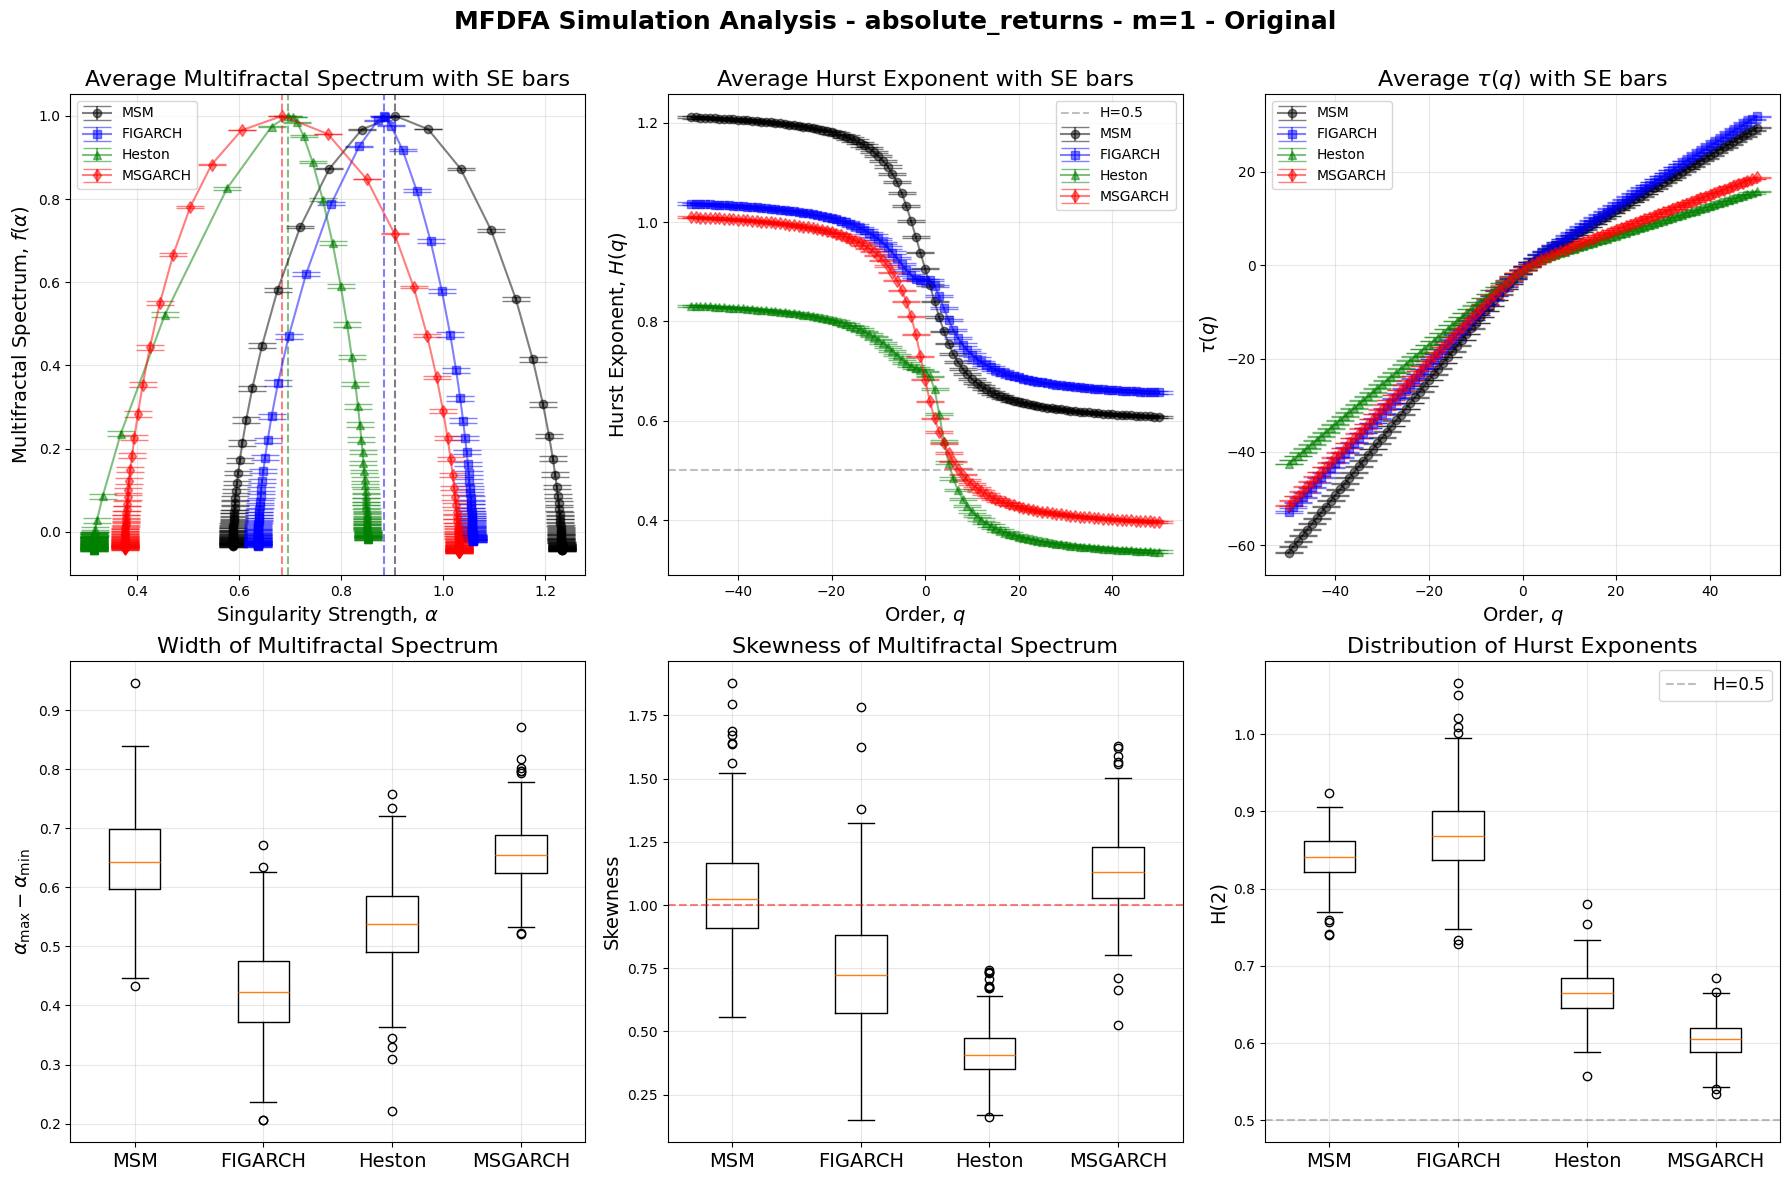

In [3]:
data_msm = np.load("all_paths_msm.npz")['r']
data_figarch = np.load("all_paths_figarch.npz")['r']
data_heston= np.load("all_paths_heston_jumps.npz")['r']
data_msgarch = np.load("all_paths_msgarch.npz")['r']
datas = [data_msm, data_figarch, data_heston, data_msgarch]
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_abs = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-50,
        q_max=50,
        m=1,
        steps=10,
        type=types[2],
        models=names, 
        block=None, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

analyser_abs.get_plots()


Processing model MSM, path 1/500
Processing model MSM, path 101/500
Processing model MSM, path 201/500
Processing model MSM, path 301/500
Processing model MSM, path 401/500
Processing model FIGARCH, path 1/500
Processing model FIGARCH, path 101/500
Processing model FIGARCH, path 201/500
Processing model FIGARCH, path 301/500
Processing model FIGARCH, path 401/500
Processing model Heston, path 1/500
Processing model Heston, path 101/500
Processing model Heston, path 201/500
Processing model Heston, path 301/500
Processing model Heston, path 401/500
Processing model MSGARCH, path 1/500
Processing model MSGARCH, path 101/500
Processing model MSGARCH, path 201/500
Processing model MSGARCH, path 301/500
Processing model MSGARCH, path 401/500


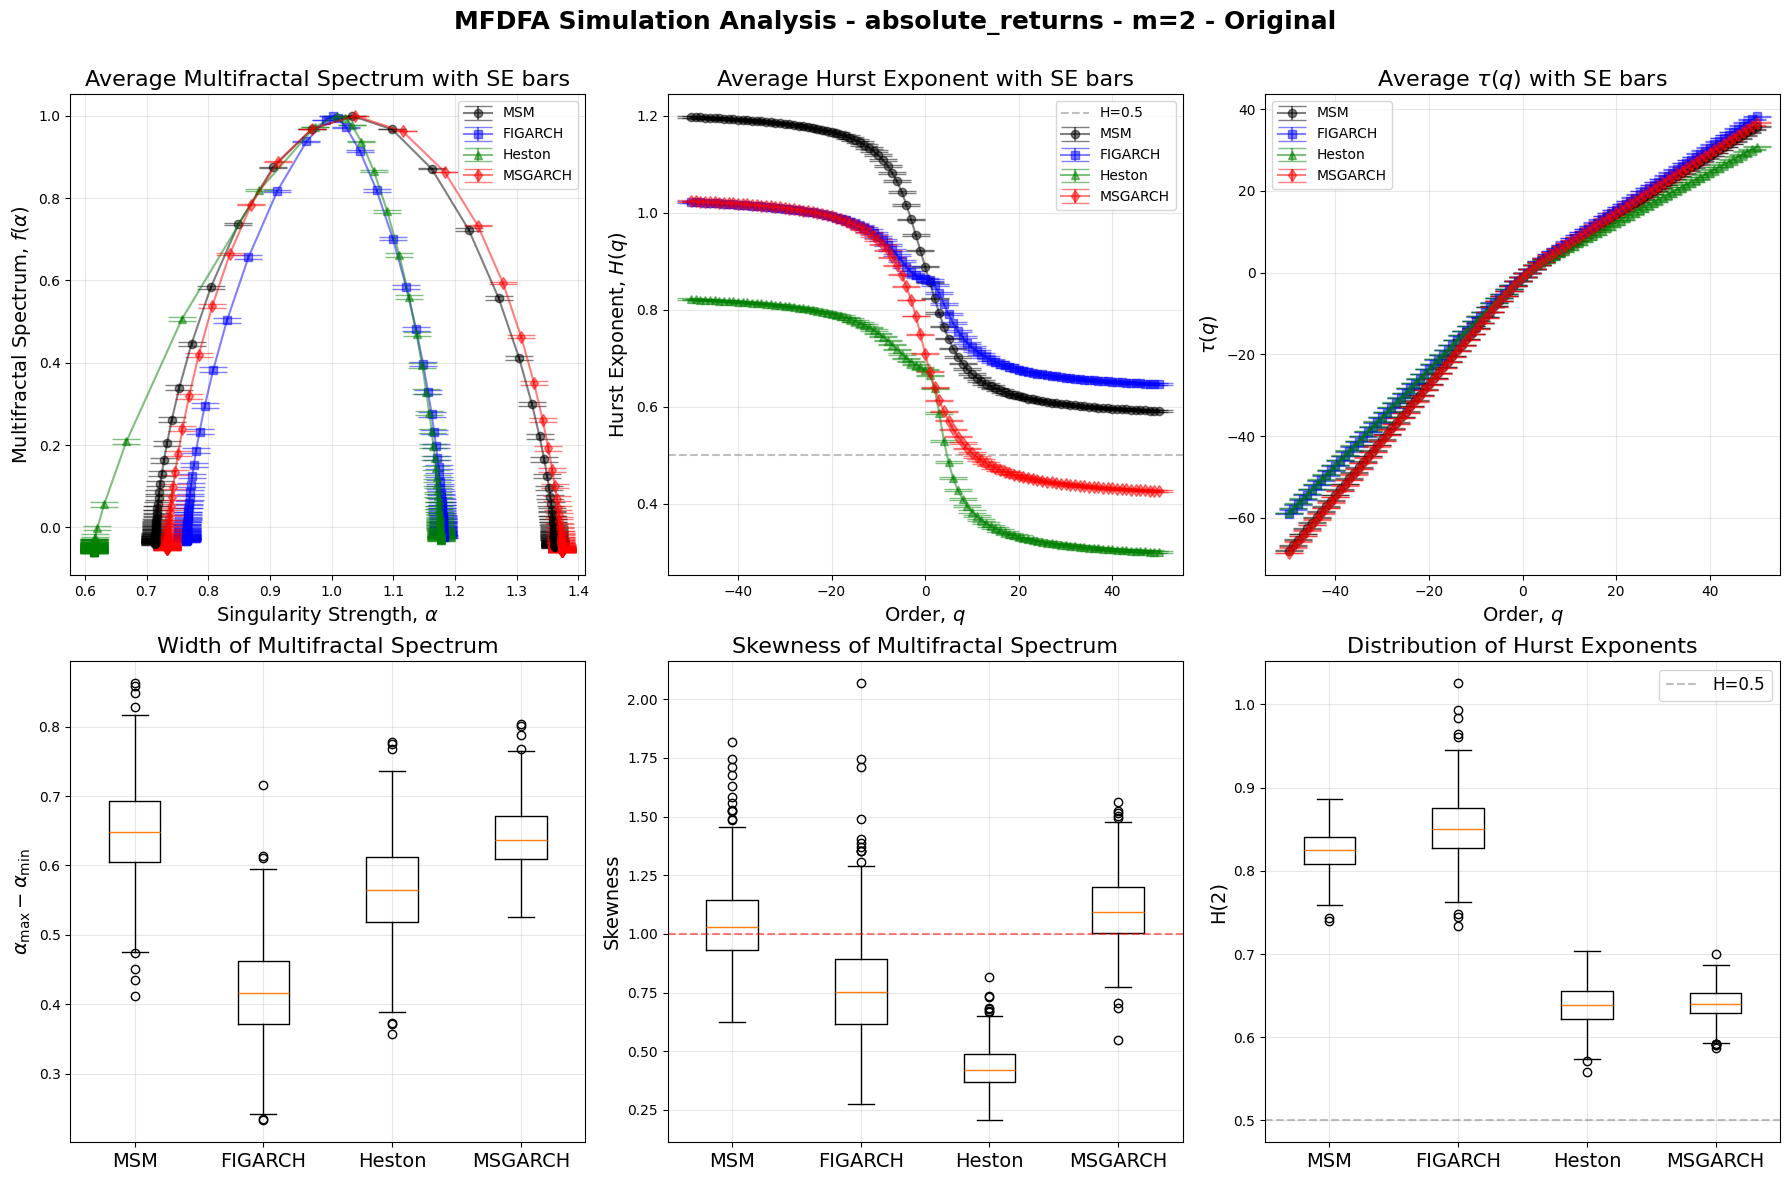

In [10]:
data_msm = np.load("all_paths_msm.npz")['r']
data_figarch = np.load("all_paths_figarch.npz")['r']
data_heston= np.load("all_paths_heston_jumps.npz")['r']
data_msgarch = np.load("all_paths_msgarch.npz")['r']
datas = [data_msm, data_figarch, data_heston, data_msgarch]
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_abs = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-50,
        q_max=50,
        m=2,
        steps=10,
        type=types[2],
        models=names, 
        block=None, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

analyser_abs.get_plots()


Processing model MSM, path 1/500
Processing model MSM, path 101/500
Processing model MSM, path 201/500
Processing model MSM, path 301/500
Processing model MSM, path 401/500
Processing model FIGARCH, path 1/500
Processing model FIGARCH, path 101/500
Processing model FIGARCH, path 201/500
Processing model FIGARCH, path 301/500
Processing model FIGARCH, path 401/500
Processing model Heston, path 1/500
Processing model Heston, path 101/500
Processing model Heston, path 201/500
Processing model Heston, path 301/500
Processing model Heston, path 401/500
Processing model MSGARCH, path 1/500
Processing model MSGARCH, path 101/500
Processing model MSGARCH, path 201/500
Processing model MSGARCH, path 301/500
Processing model MSGARCH, path 401/500


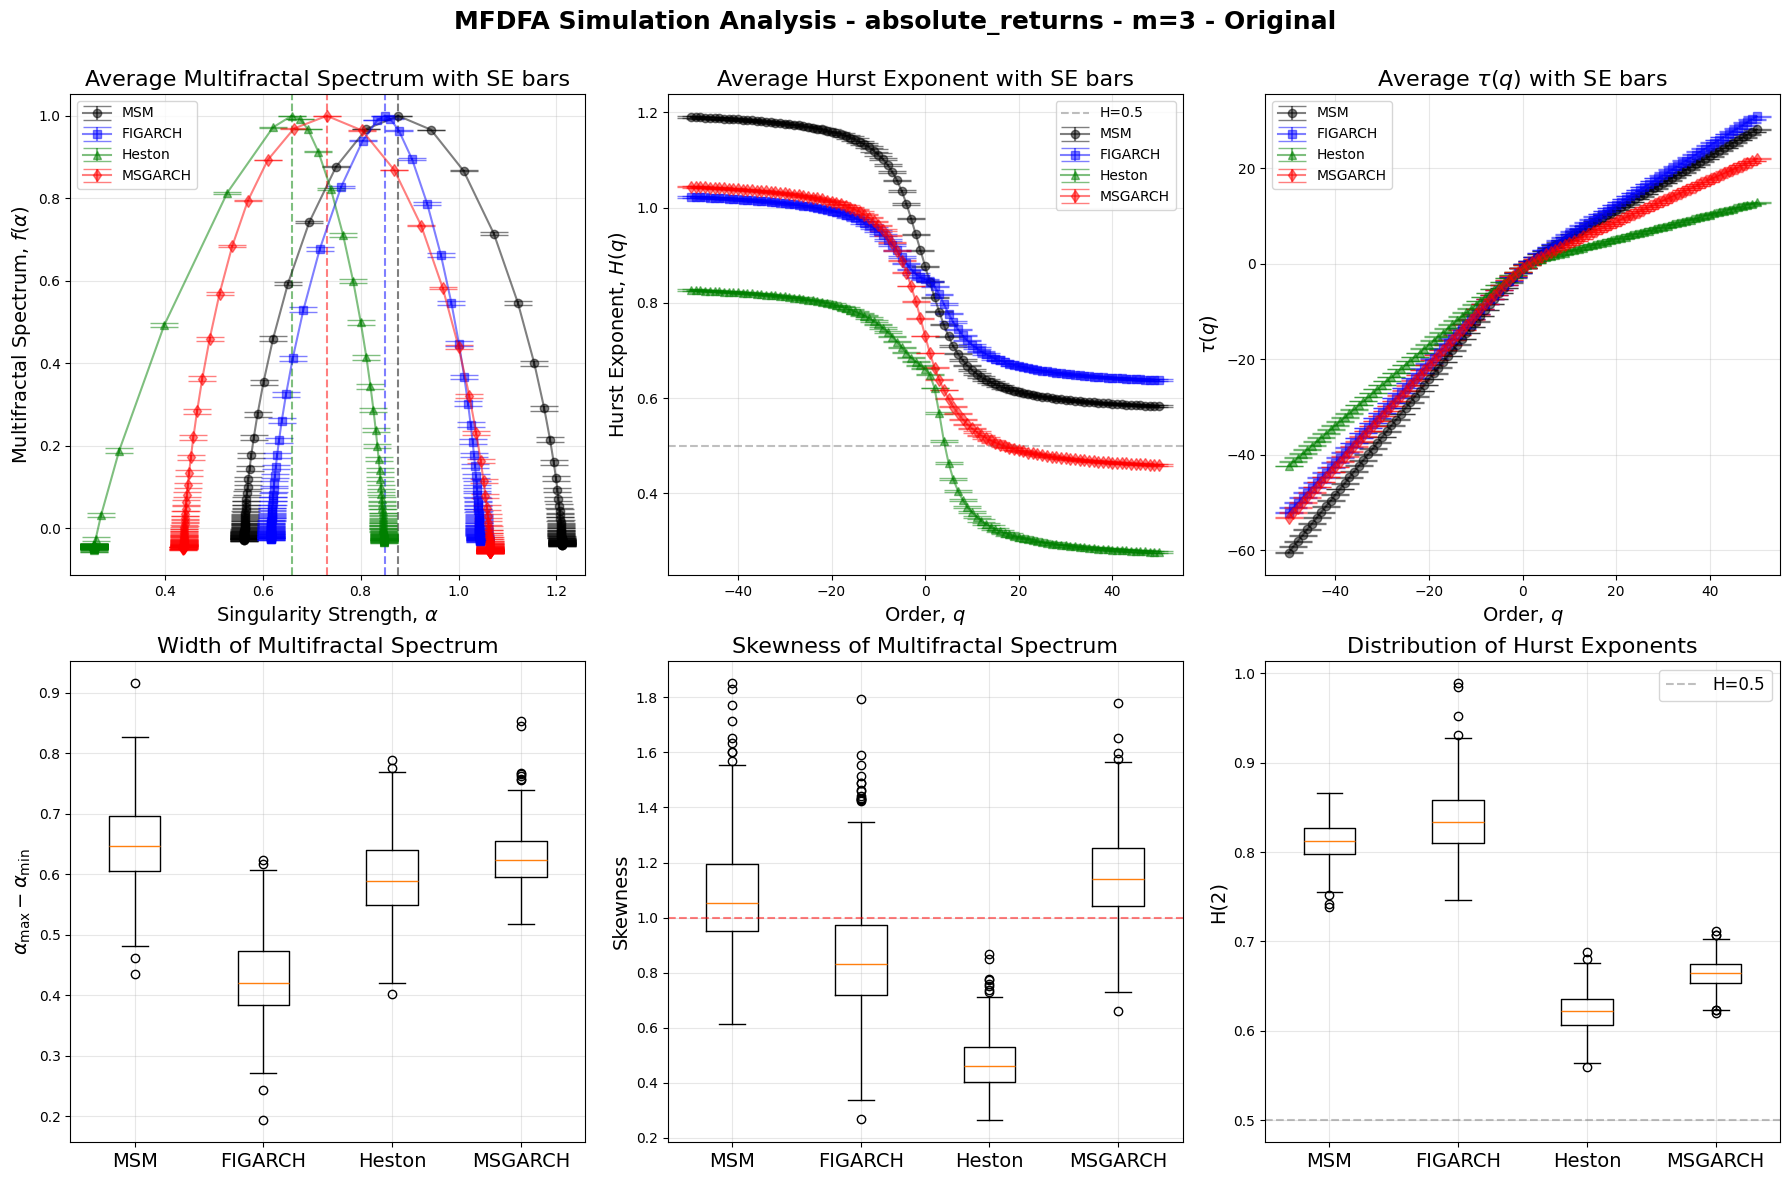

In [4]:
data_msm = np.load("all_paths_msm.npz")['r']
data_figarch = np.load("all_paths_figarch.npz")['r']
data_heston= np.load("all_paths_heston_jumps.npz")['r']
data_msgarch = np.load("all_paths_msgarch.npz")['r']
datas = [data_msm, data_figarch, data_heston, data_msgarch]
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_abs = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-50,
        q_max=50,
        m=3,
        steps=10,
        type=types[2],
        models=names, 
        block=None, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

analyser_abs.get_plots()


Processing model MSM, path 1/500
Processing model MSM, path 101/500
Processing model MSM, path 201/500
Processing model MSM, path 301/500
Processing model MSM, path 401/500
Processing model FIGARCH, path 1/500
Processing model FIGARCH, path 101/500
Processing model FIGARCH, path 201/500
Processing model FIGARCH, path 301/500
Processing model FIGARCH, path 401/500
Processing model Heston, path 1/500
Processing model Heston, path 101/500
Processing model Heston, path 201/500
Processing model Heston, path 301/500
Processing model Heston, path 401/500
Processing model MSGARCH, path 1/500
Processing model MSGARCH, path 101/500
Processing model MSGARCH, path 201/500
Processing model MSGARCH, path 301/500
Processing model MSGARCH, path 401/500


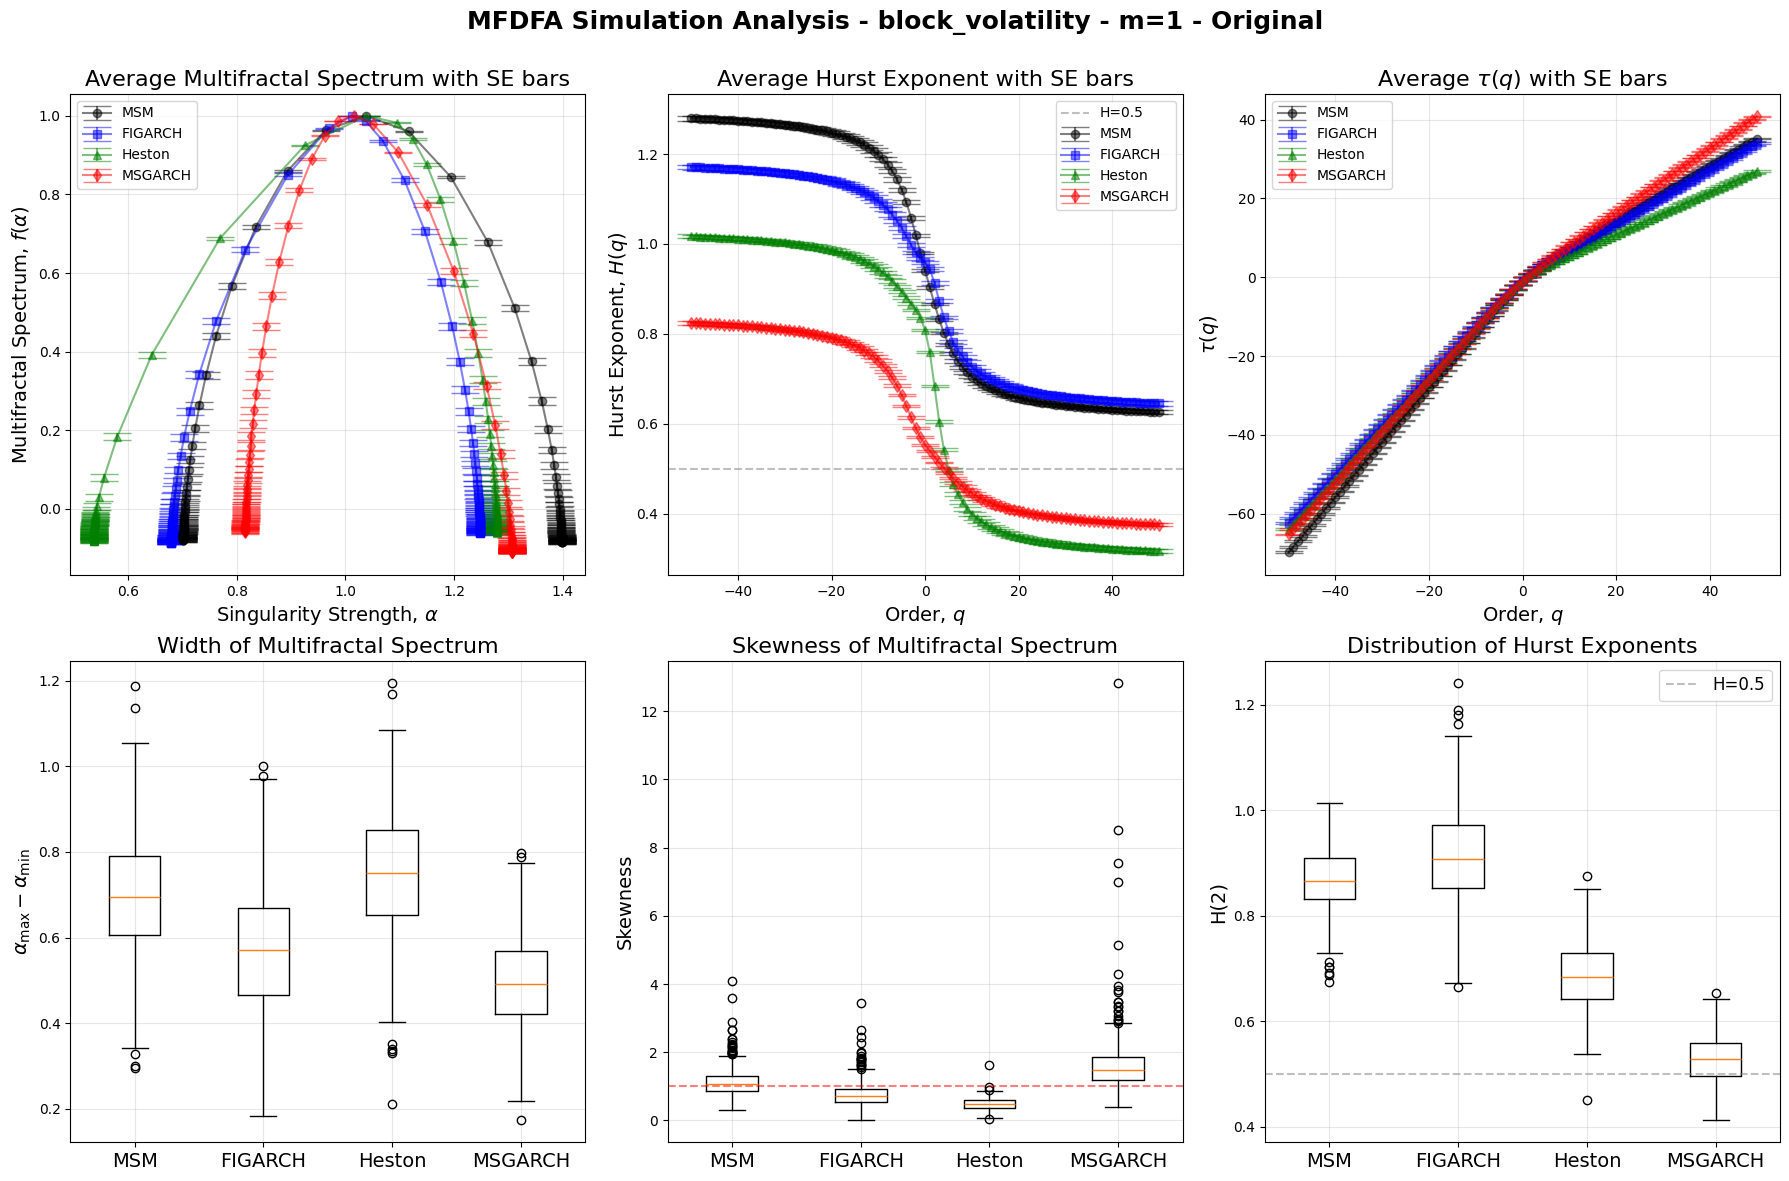

In [12]:
data_msm = np.load("all_paths_msm.npz")['r']
data_figarch = np.load("all_paths_figarch.npz")['r']
data_heston= np.load("all_paths_heston_jumps.npz")['r']
data_msgarch = np.load("all_paths_msgarch.npz")['r']
datas = [data_msm, data_figarch, data_heston, data_msgarch]
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_bv = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-50,
        q_max=50,
        m=1,
        steps=10,
        type=types[3],
        models=names, 
        block=10, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

analyser_bv.get_plots()


Processing model MSM, path 1/500
Processing model MSM, path 101/500
Processing model MSM, path 201/500
Processing model MSM, path 301/500
Processing model MSM, path 401/500
Processing model FIGARCH, path 1/500
Processing model FIGARCH, path 101/500
Processing model FIGARCH, path 201/500
Processing model FIGARCH, path 301/500
Processing model FIGARCH, path 401/500
Processing model Heston, path 1/500
Processing model Heston, path 101/500
Processing model Heston, path 201/500
Processing model Heston, path 301/500
Processing model Heston, path 401/500
Processing model MSGARCH, path 1/500
Processing model MSGARCH, path 101/500
Processing model MSGARCH, path 201/500
Processing model MSGARCH, path 301/500
Processing model MSGARCH, path 401/500


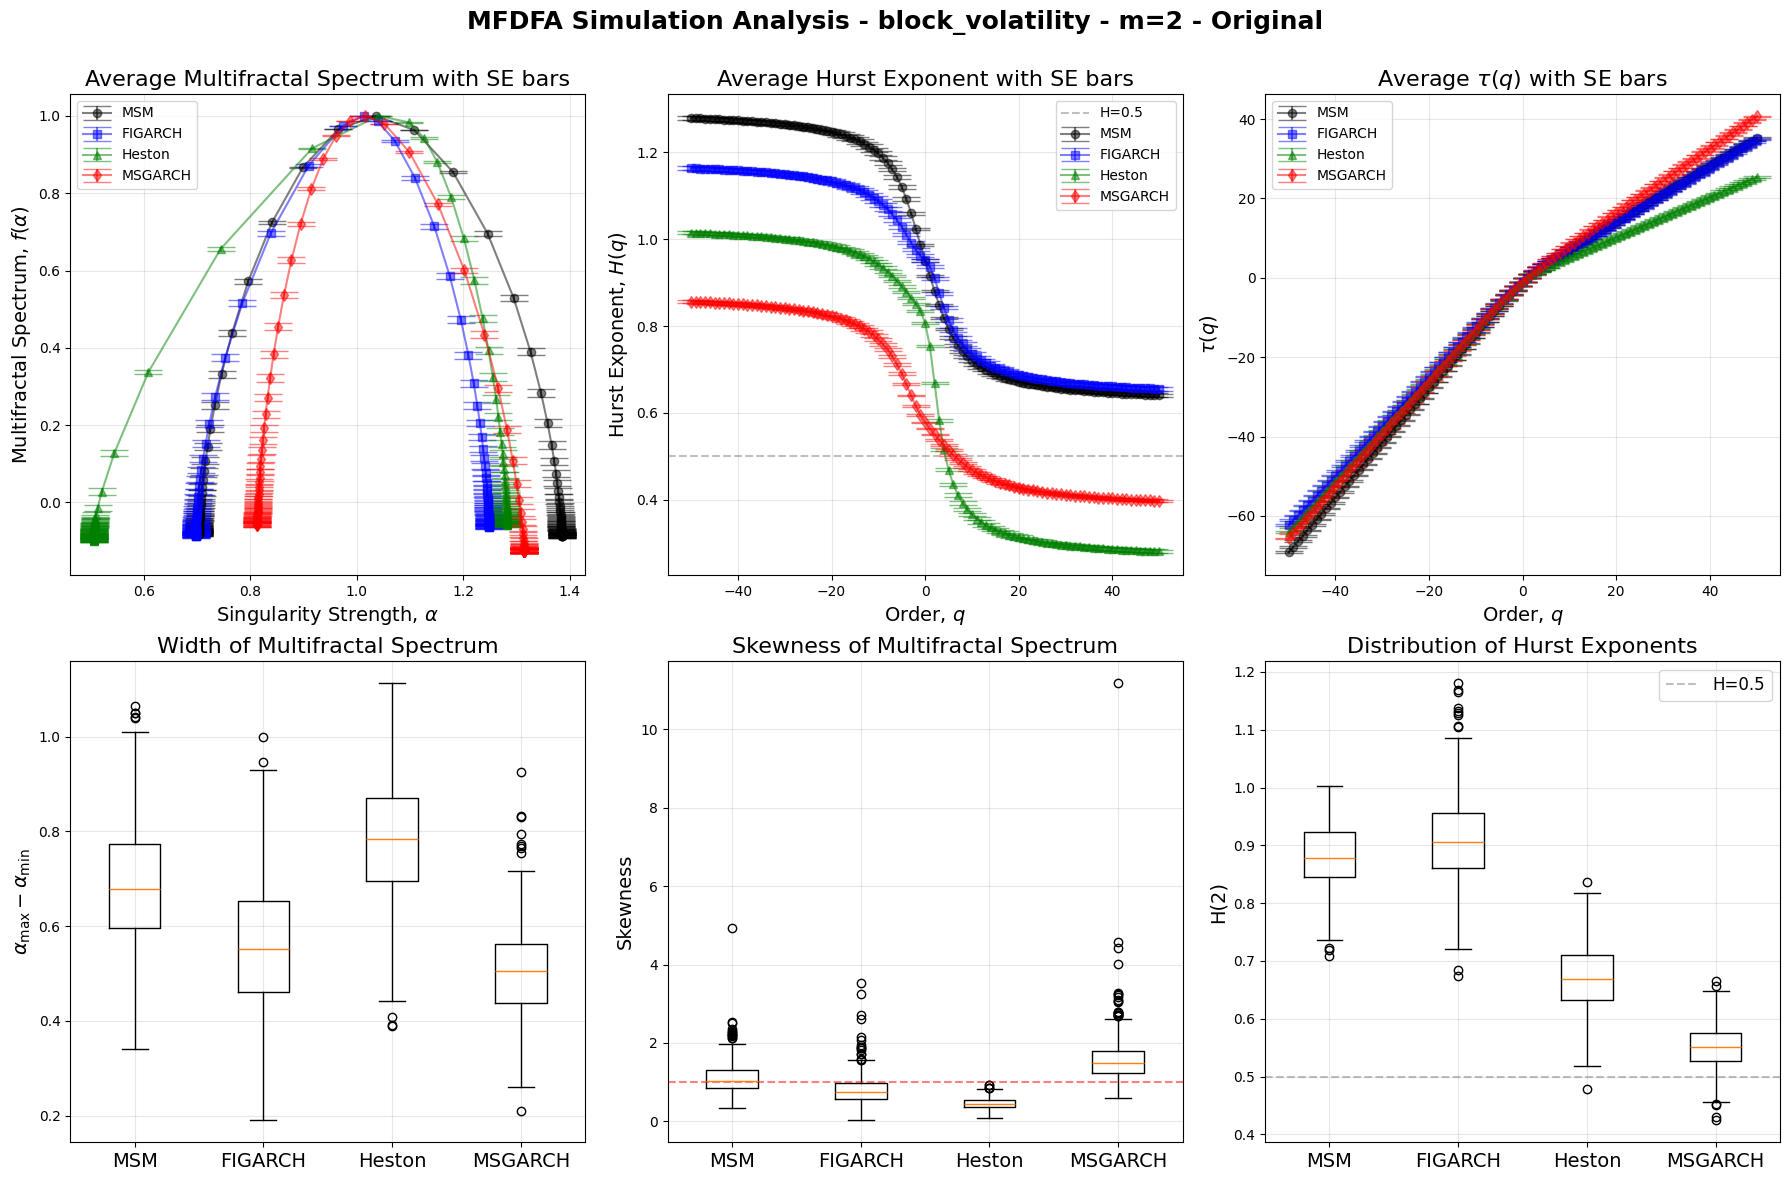

In [13]:
data_msm = np.load("all_paths_msm.npz")['r']
data_figarch = np.load("all_paths_figarch.npz")['r']
data_heston= np.load("all_paths_heston_jumps.npz")['r']
data_msgarch = np.load("all_paths_msgarch.npz")['r']
datas = [data_msm, data_figarch, data_heston, data_msgarch]
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_bv = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-50,
        q_max=50,
        m=2,
        steps=10,
        type=types[3],
        models=names, 
        block=10, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

analyser_bv.get_plots()


Processing model MSM, path 1/500
Processing model MSM, path 101/500
Processing model MSM, path 201/500
Processing model MSM, path 301/500
Processing model MSM, path 401/500
Processing model FIGARCH, path 1/500
Processing model FIGARCH, path 101/500
Processing model FIGARCH, path 201/500
Processing model FIGARCH, path 301/500
Processing model FIGARCH, path 401/500
Processing model Heston, path 1/500
Processing model Heston, path 101/500
Processing model Heston, path 201/500
Processing model Heston, path 301/500
Processing model Heston, path 401/500
Processing model MSGARCH, path 1/500
Processing model MSGARCH, path 101/500
Processing model MSGARCH, path 201/500
Processing model MSGARCH, path 301/500
Processing model MSGARCH, path 401/500


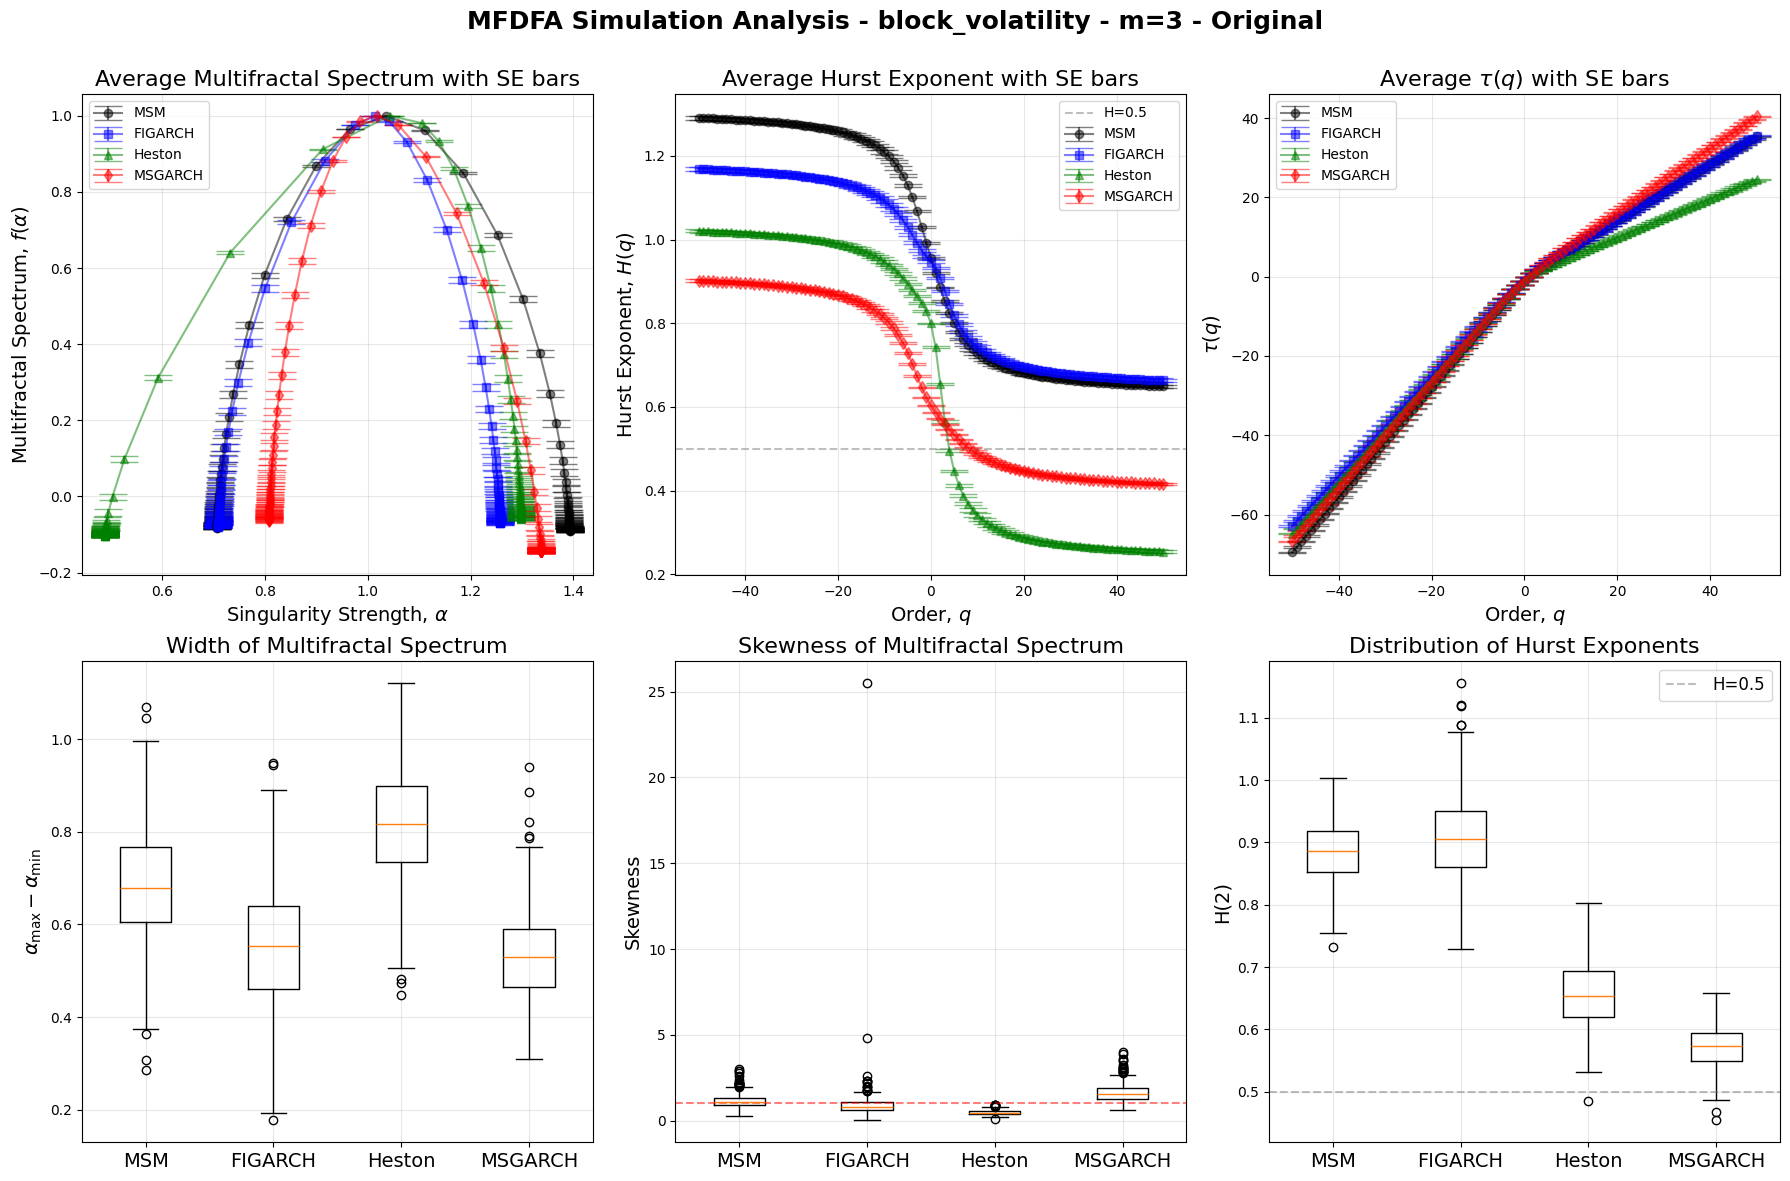

In [14]:
data_msm = np.load("all_paths_msm.npz")['r']
data_figarch = np.load("all_paths_figarch.npz")['r']
data_heston= np.load("all_paths_heston_jumps.npz")['r']
data_msgarch = np.load("all_paths_msgarch.npz")['r']
datas = [data_msm, data_figarch, data_heston, data_msgarch]
names = ["MSM", "FIGARCH", "Heston", "MSGARCH"]  
types = ['raw_log_returns', 'squared_returns', 'absolute_returns', 'block_volatility']

analyser_bv = MFDFA_Analysis_Simulation(
        datas=datas,
        burn_in=500,
        s_min=10,
        q_min=-50,
        q_max=50,
        m=3,
        steps=10,
        type=types[3],
        models=names, 
        block=10, 
        plots=True, 
        shuffle=False, 
        compare_to_shuffle_ind=False, 
        n_surrogates=100,
        accuracy_surrogates=5.0,  # defalt
        prop_sims_for_surr=10  # Use every 10th path for surrogates (50 paths total)
    )

analyser_bv.get_plots()


Consider with non normalised tao. 

Processing model MSM, path 1/500
Processing model MSM, path 101/500
Processing model MSM, path 201/500
Processing model MSM, path 301/500
Processing model MSM, path 401/500
Processing model FIGARCH, path 1/500
Processing model FIGARCH, path 101/500
Processing model FIGARCH, path 201/500
Processing model FIGARCH, path 301/500
Processing model FIGARCH, path 401/500
Processing model Heston, path 1/500
Processing model Heston, path 101/500
Processing model Heston, path 201/500
Processing model Heston, path 301/500
Processing model Heston, path 401/500
Processing model MSGARCH, path 1/500
Processing model MSGARCH, path 101/500
Processing model MSGARCH, path 201/500
Processing model MSGARCH, path 301/500
Processing model MSGARCH, path 401/500


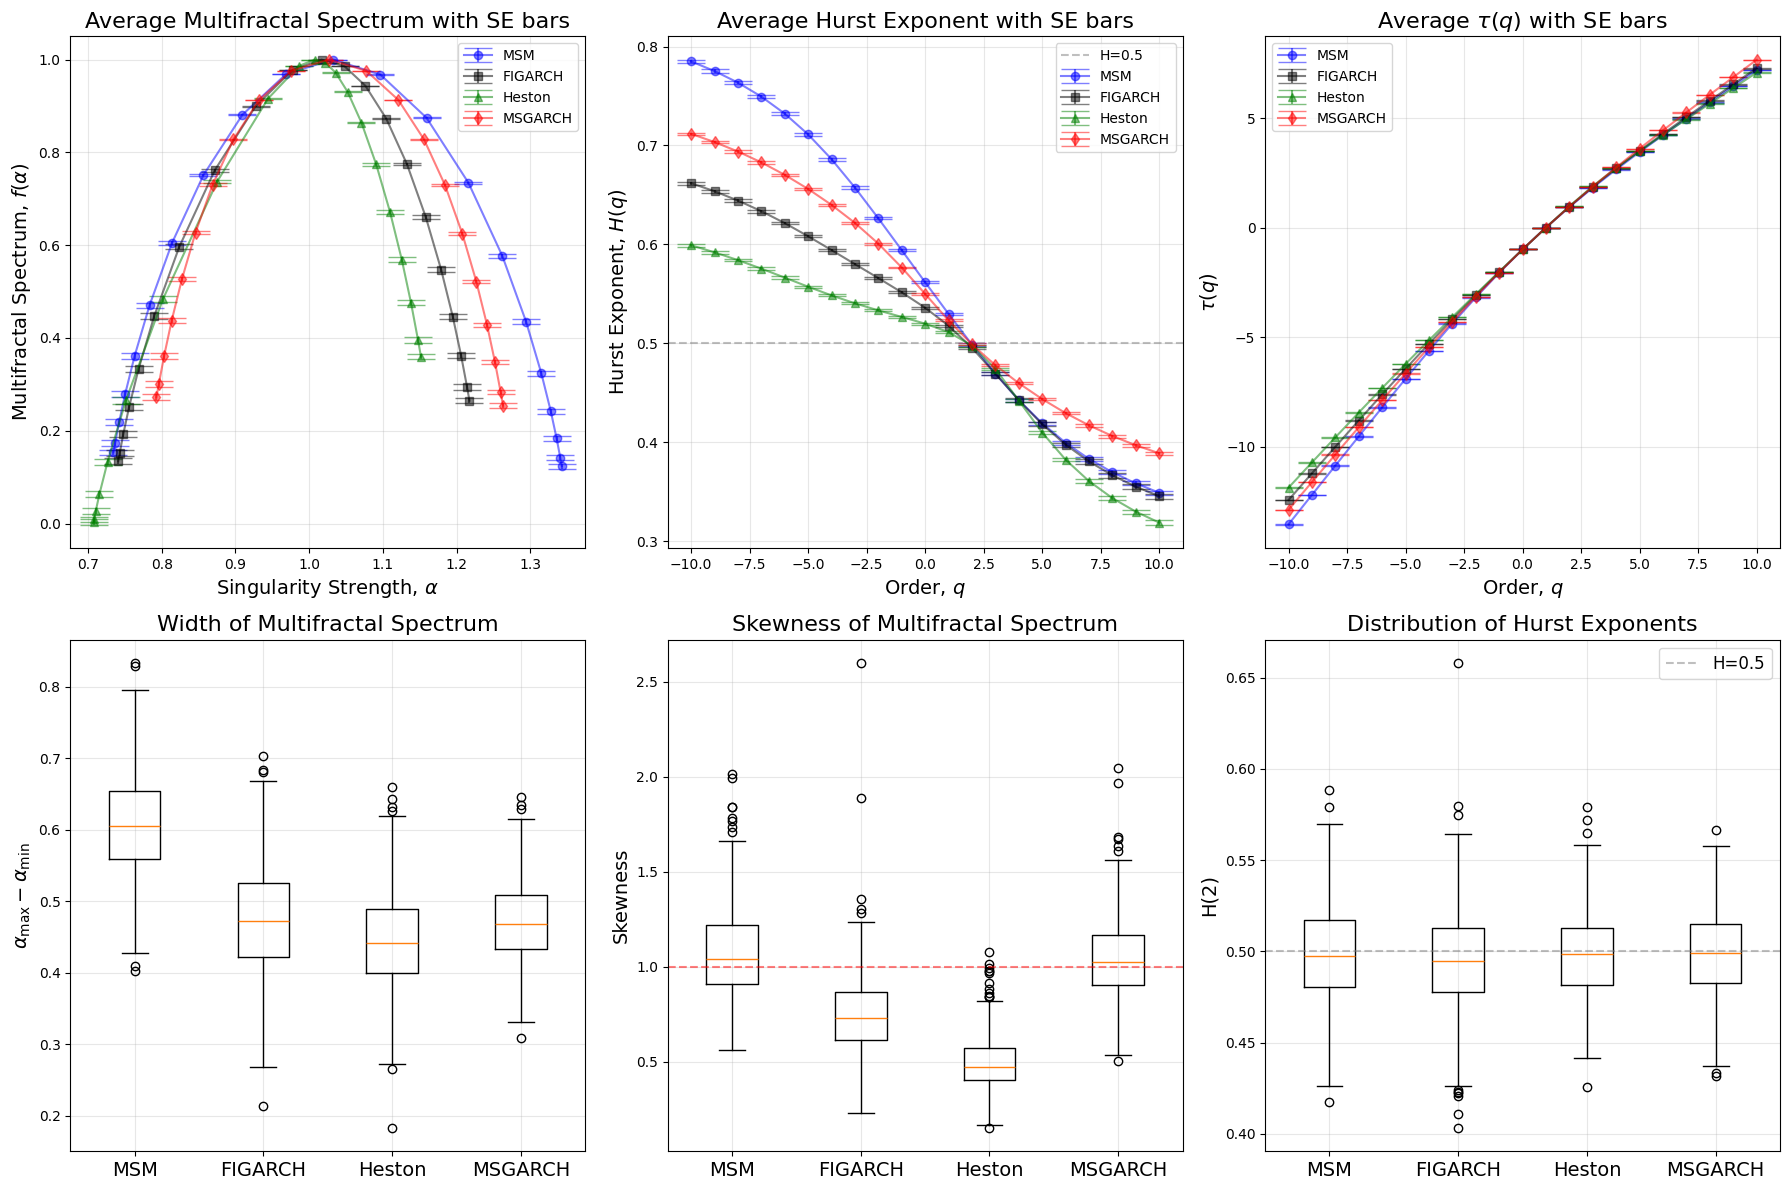

In [4]:
analyser_raw_log_r.get_plots()

Processing model MSM, path 1/500
Processing model MSM, path 101/500
Processing model MSM, path 201/500
Processing model MSM, path 301/500
Processing model MSM, path 401/500
Processing model FIGARCH, path 1/500
Processing model FIGARCH, path 101/500
Processing model FIGARCH, path 201/500
Processing model FIGARCH, path 301/500
Processing model FIGARCH, path 401/500
Processing model Heston, path 1/500
Processing model Heston, path 101/500
Processing model Heston, path 201/500
Processing model Heston, path 301/500
Processing model Heston, path 401/500
Processing model MSGARCH, path 1/500
Processing model MSGARCH, path 101/500
Processing model MSGARCH, path 201/500
Processing model MSGARCH, path 301/500
Processing model MSGARCH, path 401/500


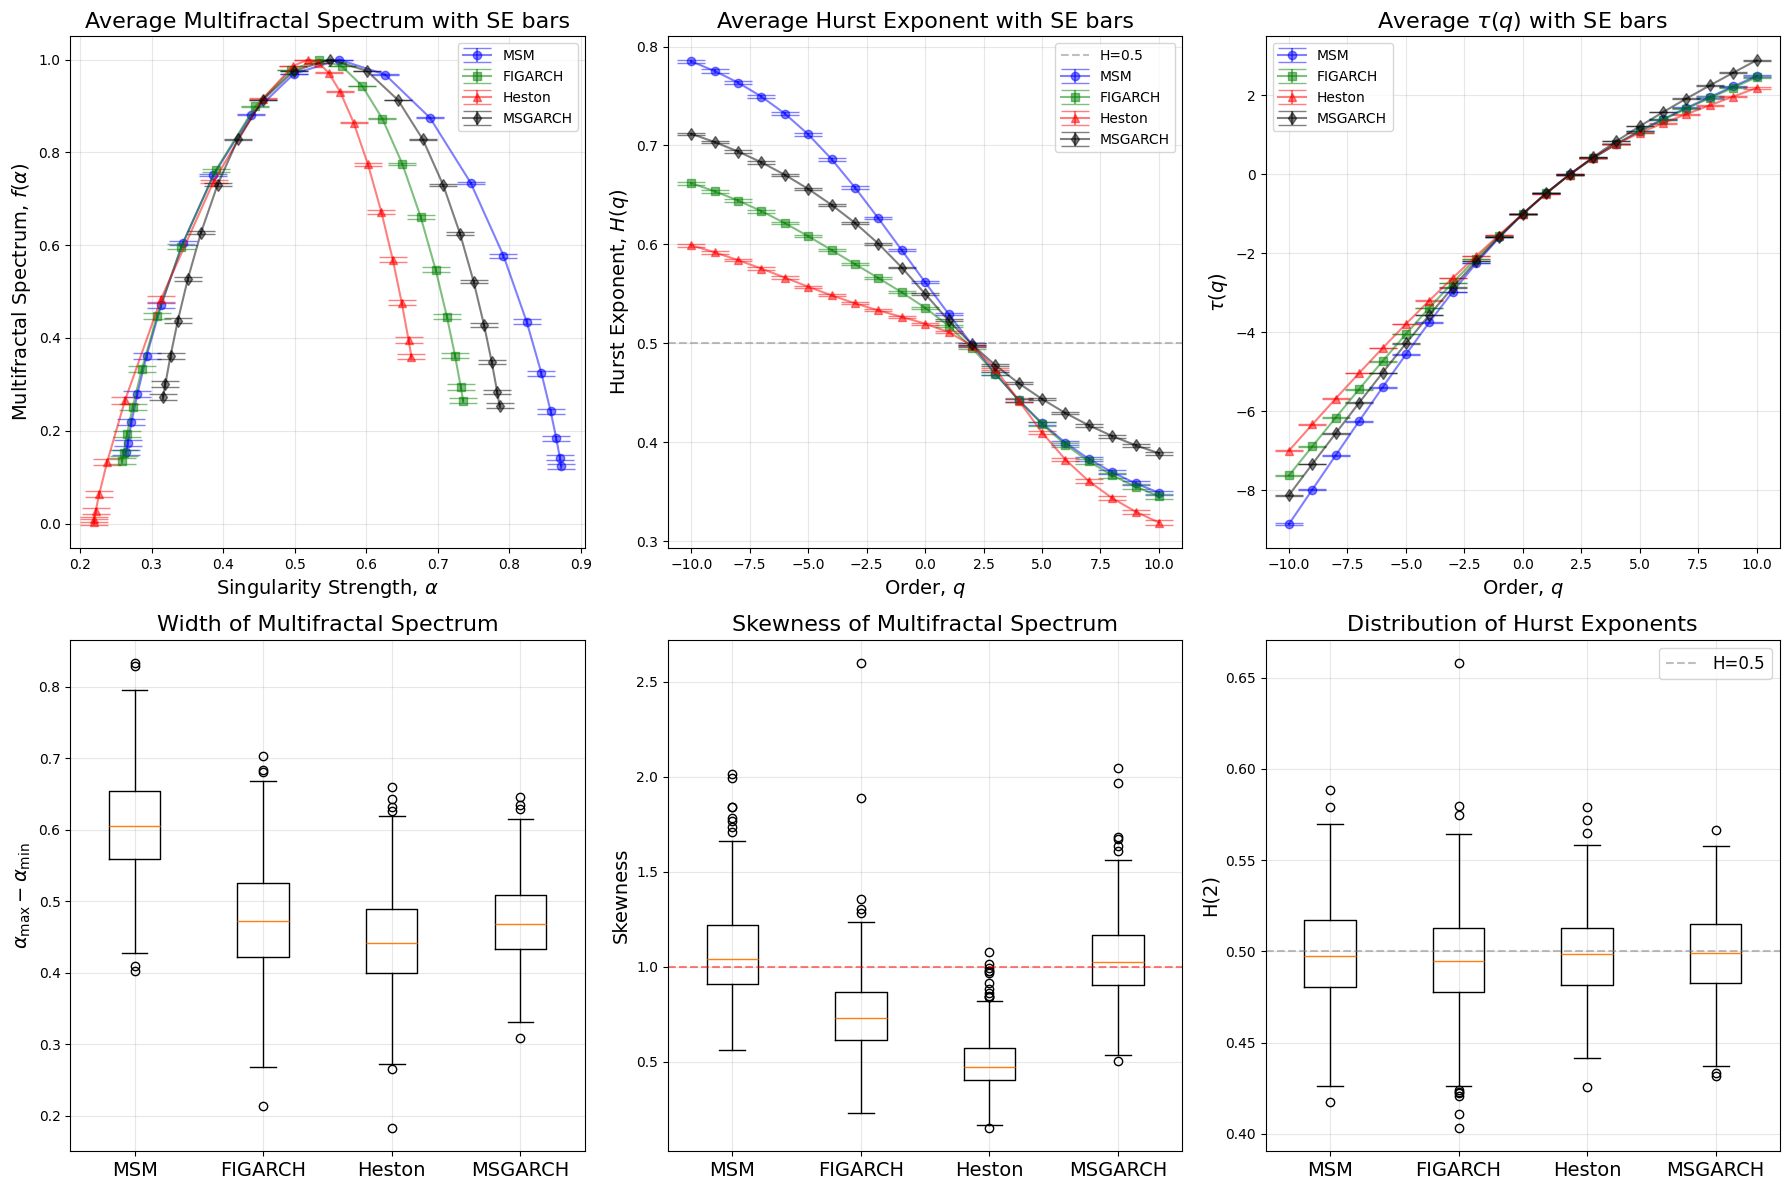

In [4]:
analyser_raw_log_r.get_plots()